## ANN (Split Validation)


### ANN — Base Model

Loads the ABS-aware Field dataset, standardizes features, trains a 64–32–16 ANN (Adam, 20 epochs) on an 80/20 split, and reports hold-out **R²/MSE/MAE** with training/validation curves.


Epoch 1/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0060 - mae: 0.0514 - mse: 0.0060 - val_loss: 0.0032 - val_mae: 0.0371 - val_mse: 0.0032
Epoch 2/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037 - mae: 0.0402 - mse: 0.0037 - val_loss: 0.0028 - val_mae: 0.0353 - val_mse: 0.0028
Epoch 3/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0384 - mse: 0.0033 - val_loss: 0.0027 - val_mae: 0.0348 - val_mse: 0.0027
Epoch 4/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0027 - val_mae: 0.0345 - val_mse: 0.0027
Epoch 5/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0373 - mse: 0.0031 - val_loss: 0.0027 - val_mae: 0.0343 - val_mse: 0.0027
Epoch 6/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0027 - val_mae: 0.0344 - val_mse: 0.0027
Epoch 7/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - mae: 0.0367 - mse: 0.0030 - val

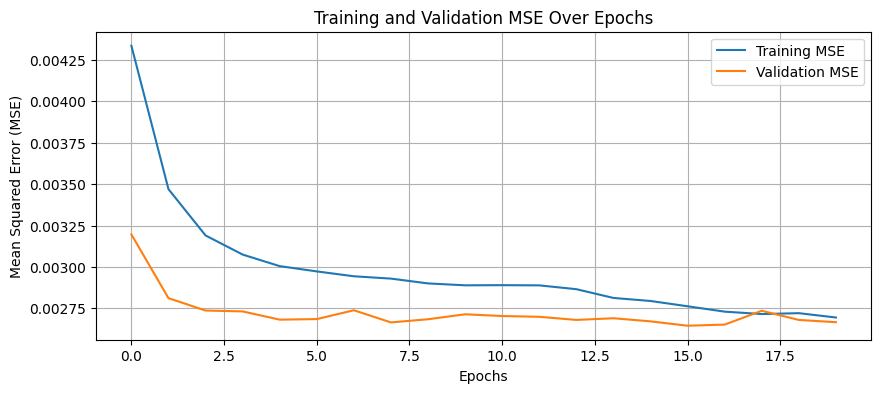

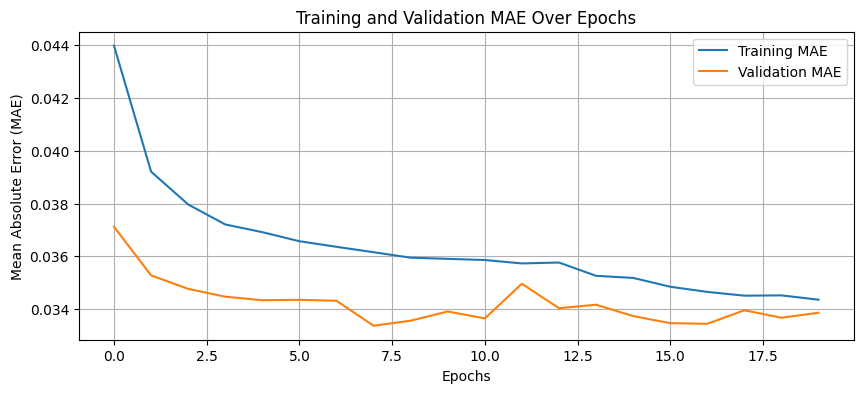

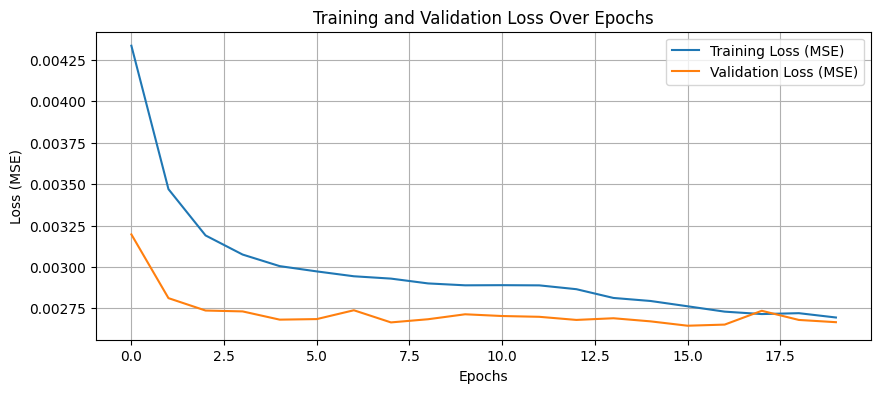

In [2]:
# **Step 1: Import Required Libraries**
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import random


# Set random seeds for reproducibility
seed_value = 42  # Change this if needed
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# **Step 2: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 3: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# **Step 4: Ensure Data is Numeric**
df = df.apply(pd.to_numeric, errors='coerce')  # Convert non-numeric values to NaN

# **Step 5: Drop Missing Values**
df.dropna(subset=features + [target], inplace=True)  # Ensure selected features & target have values

# **Step 6: Check if Data is Empty**
if df.empty:
    raise ValueError("Dataset is empty after preprocessing! Check the input file or preprocessing steps.")

# **Step 7: Split Data into Train & Test Sets**
X = df[features]
y = df[target]

if X.shape[0] < 2:  # Ensure there is enough data
    raise ValueError("Not enough samples after preprocessing to split into train and test sets.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 8: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# **Step 9: Define & Normalize ANN Model**
norm_layer = layers.Normalization()
norm_layer.adapt(X_train_prep)

# **Step 10: Define the ANN Model**
model = keras.Sequential([
    norm_layer,  # Apply normalization
    layers.Dense(64, activation="relu"),  # First hidden layer
    layers.Dense(32, activation="relu"),  # Second hidden layer
    layers.Dense(16, activation="relu"),  # Third hidden layer
    layers.Dense(1)  # Output layer (for regression)
])

# **Step 11: Compile the Model**
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss="mse",  # Mean Squared Error for regression
    metrics=["mse", "mae"]  # Track MSE & MAE
)

# **Step 12: Train the Model**
history = model.fit(
    X_train_prep, y_train,
    epochs=20,
    validation_data=(X_test_prep, y_test),
    batch_size=8,
    verbose=1
)

# **Step 13: Evaluate the Model**
test_loss, test_mse, test_mae = model.evaluate(X_test_prep, y_test, verbose=1)

# **Step 14: Compute R² Score**
y_pred = model.predict(X_test_prep)
test_r2 = r2_score(y_test, y_pred)

# **Step 15: Print Evaluation Metrics**
print(f"\nTest Loss (MSE): {test_loss:.6f}")
print(f"Test MSE: {test_mse:.6f}")
print(f"Test MAE: {test_mae:.6f}")
print(f"Test R² Score: {test_r2:.6f}")

# **Step 16: Plot Training & Validation Performance**
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)

# **Plot MSE**
plt.figure(figsize=(10, 4))
plt.plot(history_df['mse'], label='Training MSE')
plt.plot(history_df['val_mse'], label='Validation MSE')
plt.title('Training and Validation MSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot MAE**
plt.figure(figsize=(10, 4))
plt.plot(history_df['mae'], label='Training MAE')
plt.plot(history_df['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot Loss**
plt.figure(figsize=(10, 4))
plt.plot(history_df['loss'], label='Training Loss (MSE)')
plt.plot(history_df['val_loss'], label='Validation Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()



### ANN — Batch-Size Sweep 

Keeps the 64–32–16 architecture fixed and evaluates batch sizes 6–64 on an 80/20 split to assess sensitivity (reports R²/MSE/MAE).



🔥 Training Model with Batch Size: 6
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Stored results for Batch Size: 6

🔥 Training Model with Batch Size: 8
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
✅ Stored results for Batch Size: 8

🔥 Training Model with Batch Size: 10
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Stored results for Batch Size: 10

🔥 Training Model with Batch Size: 12
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Stored results for Batch Size: 12

🔥 Training Model with Batch Size: 16
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Stored results for Batch Size: 16

🔥 Training Model with Batch Size: 20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Stored results for Batch Size: 20

🔥 Training Model with Batch Size: 24
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
✅ Stored results for Batch Size: 24

🔥 Training Model with Batch Size: 32
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
✅ Stored results for Batch Size: 32

🔥 Training Model with Batch Size: 40
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
✅ Stored results for 

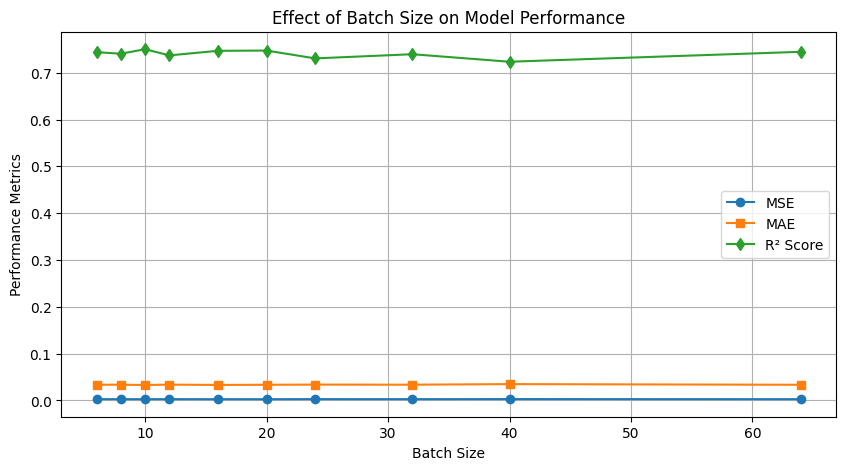

In [3]:
# **Step 1: Import Required Libraries**
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import matplotlib.pyplot as plt

# **Set Random Seeds for Reproducibility**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)


# **Step 2: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 3: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# **Step 4: Ensure Data is Numeric**
df = df.apply(pd.to_numeric, errors='coerce')

# **Step 5: Drop Missing Values**
df.dropna(subset=features + [target], inplace=True)

# **Step 6: Check if Data is Empty**
if df.empty:
    raise ValueError("Dataset is empty after preprocessing! Check the input file or preprocessing steps.")

# **Step 7: Split Data into Train & Test Sets**
X = df[features]
y = df[target]

if X.shape[0] < 2:
    raise ValueError("Not enough samples after preprocessing to split into train and test sets.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 8: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# **Step 9: Define Function to Create ANN Model**
def create_model():
    norm_layer = layers.Normalization()
    norm_layer.adapt(X_train_prep)
    
    model = keras.Sequential([
        norm_layer,
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)  # Output layer (for regression)
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mse", "mae"])
    
    return model

# **Step 10: Test Different Batch Sizes**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training Model with Batch Size: {batch_size}")
    
    # Create a fresh model for each batch size
    model = create_model()
    
    # Train the model
    history = model.fit(
        X_train_prep, y_train,
        epochs=20,
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        verbose=0  # Silent training
    )

    # Evaluate model performance
    test_loss, test_mse, test_mae = model.evaluate(X_test_prep, y_test, verbose=0)

    # Compute R² Score
    y_pred = model.predict(X_test_prep)
    test_r2_final = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })
    
    print(f"✅ Stored results for Batch Size: {batch_size}")

# **Step 11: Convert Results to DataFrame & Display**
results_df = pd.DataFrame(results)
print("\n🔥 **ANN Batch Size Results:**")
print(results_df)

# **Step 12: Plot Results**
plt.figure(figsize=(10, 5))
plt.plot(results_df["Batch Size"], results_df["Test MSE"], label="MSE", marker='o')
plt.plot(results_df["Batch Size"], results_df["Test MAE"], label="MAE", marker='s')
plt.plot(results_df["Batch Size"], results_df["Test R² Score"], label="R² Score", marker='d')
plt.xlabel("Batch Size")
plt.ylabel("Performance Metrics")
plt.title("Effect of Batch Size on Model Performance")
plt.legend()
plt.grid(True)
plt.show()


### ANN — Final (Reporting Run)

Selects batch size via **train-only** validation (no test leakage), retrains the 64–32–16 ANN on an 80/20 split with StandardScaler (no double normalization), and reports hold-out **R²/MSE/MAE** with a validation-MSE vs. batch-size plot.



Training Model with Batch Size: 6

Training Model with Batch Size: 8

Training Model with Batch Size: 10

Training Model with Batch Size: 12

Training Model with Batch Size: 16

Training Model with Batch Size: 20

Training Model with Batch Size: 24

Training Model with Batch Size: 32

Training Model with Batch Size: 40

Training Model with Batch Size: 64

Selected best batch size (by lowest val_loss): 6

**ANN Final Result (Field, with best batch size):**
{'Batch Size': 6, 'Test MSE': 0.0026580658741295338, 'Test MAE': 0.032817624509334564, 'Test R² Score': 0.7425210913107008}


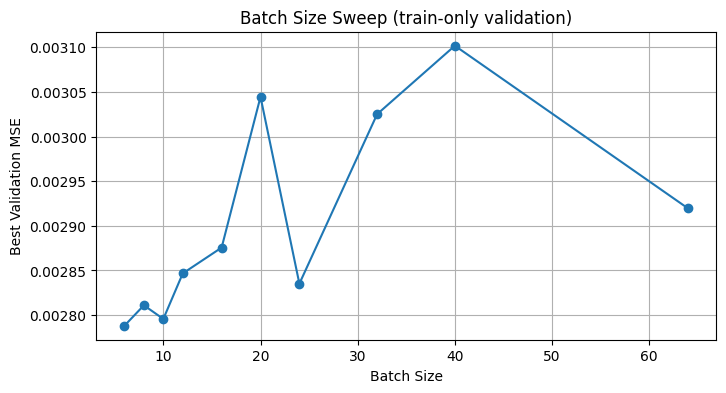

In [4]:
# **Step 1: Import Required Libraries**
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import matplotlib.pyplot as plt

# **Set Random Seeds for Reproducibility**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# **Step 2: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 3: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# **Step 4: Ensure Data is Numeric**
df = df.apply(pd.to_numeric, errors='coerce')

# **Step 5: Drop Missing Values**
df.dropna(subset=features + [target], inplace=True)

# **Step 6: Check if Data is Empty**
if df.empty:
    raise ValueError("Dataset is empty after preprocessing! Check the input file or preprocessing steps.")

# **Step 7: Split Data into Train & Test Sets**
X = df[features]
y = df[target]

if X.shape[0] < 2:
    raise ValueError("Not enough samples after preprocessing to split into train and test sets.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 8: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# **Step 9: Define Function to Create ANN Model**
def create_model():
    # --- REMOVED to avoid double normalization (we already use StandardScaler) ---
    # norm_layer = layers.Normalization()
    # norm_layer.adapt(X_train_prep)

    model = keras.Sequential([
        # norm_layer,
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)  # Output layer (for regression)
    ])

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mse", "mae"])
    return model

# **Step 10: Test Different Batch Sizes**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []

# Track best batch size by lowest validation loss (train-only)
best_bs = None
best_val = float("inf")

for batch_size in batch_size_options:
    print(f"\nTraining Model with Batch Size: {batch_size}")
    model = create_model()

    # --- CHANGED: use train-only validation to avoid test leakage ---
    history = model.fit(
        X_train_prep, y_train,
        epochs=20,
        validation_split=0.2,   # instead of validation_data=(X_test_prep, y_test)
        batch_size=batch_size,
        verbose=0
    )

    # Track best val_loss for this batch size
    this_best_val = min(history.history["val_loss"])
    results.append({"Batch Size": batch_size, "Best Val MSE": this_best_val})
    if this_best_val < best_val:
        best_val = this_best_val
        best_bs = batch_size

print("\nSelected best batch size (by lowest val_loss):", best_bs)

# ---- Final training with chosen batch size; single evaluation on test ----
final_model = create_model()
final_model.fit(
    X_train_prep, y_train,
    epochs=20,
    validation_split=0.2,   # keep train-only validation for early stopping/monitoring if desired
    batch_size=best_bs,
    verbose=0
)

test_loss, test_mse, test_mae = final_model.evaluate(X_test_prep, y_test, verbose=0)
y_pred = final_model.predict(X_test_prep, verbose=0).ravel()   # flatten for r2_score
test_r2_final = r2_score(y_test, y_pred)

final_result = {
    "Batch Size": best_bs,
    "Test MSE": test_mse,
    "Test MAE": test_mae,
    "Test R² Score": test_r2_final
}
print("\n**ANN Final Result (Field, with best batch size):**")
print(final_result)

# **Step 12: Optional: plot validation losses per batch size**
import pandas as pd
results_df = pd.DataFrame(results)
plt.figure(figsize=(8, 4))
plt.plot(results_df["Batch Size"], results_df["Best Val MSE"], marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Best Validation MSE")
plt.title("Batch Size Sweep (train-only validation)")
plt.grid(True)
plt.show()


### ANN — Hyperparameter Tuning 
Bayesian optimization over hidden layers/units, optimizer, and learning rate; picks the best by validation **MSE**.

In [5]:

import keras_tuner as kt
import os
# ✅ Set Random Seed for Consistency
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Define the hypermodel function
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Normalization(input_shape=(X_train_prep.shape[1],)))

    # Tune the number of hidden layers (1 to 4)
    for i in range(hp.Int('n_hidden', 1, 4)):
        model.add(layers.Dense(
            units=hp.Int(f'n_neurons_{i}', min_value=16, max_value=256, step=16),
            activation='relu'
        ))

    # Output layer for regression
    model.add(layers.Dense(1))

    # Tune optimizer and learning rate
    optimizer = hp.Choice('optimizer', ['Adam', 'RMSprop', 'SGD'])
    learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.01, sampling='log')

    if optimizer == 'Adam':
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer == 'RMSprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='mse', metrics=['mse', 'mae'])
    return model

# Run Bayesian Optimization
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_mse',
    max_trials=10,  # Try 10 different architectures
    directory='hyperparam_tuning',
    project_name='ANN_Optimization'
)

# Search for the best hyperparameters
tuner.search(X_train_prep, y_train, epochs=20, validation_data=(X_test_prep, y_test), verbose=1)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best number of hidden layers: {best_hps.get('n_hidden')}")
print(f"Best number of neurons per layer: {[best_hps.get(f'n_neurons_{i}') for i in range(best_hps.get('n_hidden'))]}")
print(f"Best optimizer: {best_hps.get('optimizer')}")
print(f"Best learning rate: {best_hps.get('learning_rate')}")


Trial 10 Complete [00h 00m 08s]
val_mse: 0.0026900905650109053

Best val_mse So Far: 0.0025997867342084646
Total elapsed time: 00h 01m 29s
Best number of hidden layers: 4
Best number of neurons per layer: [208, 16, 16, 16]
Best optimizer: Adam
Best learning rate: 0.002051386718289359


In [6]:
# ✅ Set Random Seed for Consistency
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ Train the Final Optimized ANN Model with Different Batch Sizes
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]  # Try different batch sizes
results = []  # List to store results

for batch_size in batch_size_options:
    print(f"\n🔥 Training Optimized ANN Model with Batch Size: {batch_size}")

    # ✅ **Rebuild ANN Model with Best Hyperparameters**
    final_ann_model = keras.Sequential()
    final_ann_model.add(layers.Normalization(input_shape=(X_train_prep.shape[1],)))

    # Add Optimized Hidden Layers
    for i in range(best_hps.get('n_hidden')):
        final_ann_model.add(layers.Dense(
            units=best_hps.get(f'n_neurons_{i}'),
            activation='relu'
        ))

    # Output layer
    final_ann_model.add(layers.Dense(1))

    # Compile Model with Best Optimizer & Learning Rate
    if best_hps.get('optimizer') == 'Adam':
        opt = keras.optimizers.Adam(learning_rate=best_hps.get('learning_rate'))
    elif best_hps.get('optimizer') == 'RMSprop':
        opt = keras.optimizers.RMSprop(learning_rate=best_hps.get('learning_rate'))
    else:
        opt = keras.optimizers.SGD(learning_rate=best_hps.get('learning_rate'))

    final_ann_model.compile(optimizer=opt, loss="mse", metrics=["mse", "mae"])

    # ✅ Train Model
    history_final_ann = final_ann_model.fit(
        X_train_prep, y_train,
        epochs=50,
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # ✅ Evaluate the Model
    test_loss, test_mse, test_mae = final_ann_model.evaluate(X_test_prep, y_test, verbose=1)

    # ✅ Compute R² Score
    y_pred_final = final_ann_model.predict(X_test_prep).flatten()
    test_r2_final = r2_score(y_test, y_pred_final)

    # ✅ Store Results
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ Convert Results to DataFrame & Display
if results:
    results_df = pd.DataFrame(results)
    print("\n🔥 **ANN Batch Size Results:**")
    print(results_df)
else:
    print("⚠️ No batch size results were recorded. Check if the results list was updated inside the loop.")



🔥 Training Optimized ANN Model with Batch Size: 6
Epoch 1/50


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0077 - mae: 0.0525 - mse: 0.0077 - val_loss: 0.0030 - val_mae: 0.0348 - val_mse: 0.0030
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0036 - mae: 0.0401 - mse: 0.0036 - val_loss: 0.0029 - val_mae: 0.0353 - val_mse: 0.0029
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0394 - mse: 0.0035 - val_loss: 0.0028 - val_mae: 0.0351 - val_mse: 0.0028
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0035 - mae: 0.0391 - mse: 0.0035 - val_loss: 0.0028 - val_mae: 0.0351 - val_mse: 0.0028
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0033 - mae: 0.0384 - mse: 0.0033 - val_loss: 0.0027 - val_mae: 0.0347 - val_mse: 0.0027
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0033 - mae: 0.0383 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0352 - val_mse: 0.0028
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0033 - mae: 0.0389 - mse: 0.0033 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0046 - mae: 0.0446 - mse: 0.0046 - val_loss: 0.0029 - val_mae: 0.0353 - val_mse: 0.0029
Epoch 2/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0395 - mse: 0.0035 - val_loss: 0.0029 - val_mae: 0.0355 - val_mse: 0.0029
Epoch 3/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0392 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0351 - val_mse: 0.0029
Epoch 4/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0383 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0345 - val_mse: 0.0029
Epoch 5/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0376 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0345 - val_mse: 0.0028
Epoch 6/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0345 - val_mse: 0.0028
Epoch 7/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0032 - mae: 0.0372 - mse: 0.0032 - val_loss: 0.00

...

131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0067 - mae: 0.0534 - mse: 0.0067 - val_loss: 0.0037 - val_mae: 0.0377 - val_mse: 0.0037
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0036 - mae: 0.0398 - mse: 0.0036 - val_loss: 0.0033 - val_mae: 0.0364 - val_mse: 0.0033
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034 - mae: 0.0387 - mse: 0.0034 - val_loss: 0.0030 - val_mae: 0.0352 - val_mse: 0.0030
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.0029 - val_mae: 0.0348 - val_mse: 0.0029
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0372 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0348 - val_mse: 0.0029
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0369 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0347 - val_mse: 0.0029
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0368 - mse: 0.0031 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0049 - mae: 0.0465 - mse: 0.0049 - val_loss: 0.0033 - val_mae: 0.0364 - val_mse: 0.0033
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034 - mae: 0.0389 - mse: 0.0034 - val_loss: 0.0034 - val_mae: 0.0368 - val_mse: 0.0034
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 - mae: 0.0380 - mse: 0.0033 - val_loss: 0.0034 - val_mae: 0.0369 - val_mse: 0.0034
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - mae: 0.0380 - mse: 0.0032 - val_loss: 0.0031 - val_mae: 0.0357 - val_mse: 0.0031
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.0031 - val_mae: 0.0361 - val_mse: 0.0031
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0350 - val_mse: 0.0030
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0372 - mse: 0.0031 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0091 - mae: 0.0597 - mse: 0.0091 - val_loss: 0.0032 - val_mae: 0.0379 - val_mse: 0.0032
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 - mae: 0.0382 - mse: 0.0033 - val_loss: 0.0031 - val_mae: 0.0381 - val_mse: 0.0031
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0372 - val_mse: 0.0030
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0360 - val_mse: 0.0029
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0369 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0358 - val_mse: 0.0029
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - mae: 0.0363 - mse: 0.0030 - val_loss: 0.0029 - val_mae: 0.0356 - val_mse: 0.0029
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - mae: 0.0361 - mse: 0.0030 - val_loss: 0.0030 - val_mae: 

### Ad hoc — Manually Refined ANN

Evaluates a hand-crafted architecture/optimizer against the tuned best model and sweeps batch sizes (6–64) with early stopping; reports hold-out **R²/MSE/MAE** and a performance plot.


🔥 Training ANN Model with Batch Size: 6
Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0255 - mae: 0.0713 - mse: 0.0255 - val_loss: 0.0031 - val_mae: 0.0361 - val_mse: 0.0031
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0036 - mae: 0.0391 - mse: 0.0036 - val_loss: 0.0030 - val_mae: 0.0358 - val_mse: 0.0030
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0034 - mae: 0.0384 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0352 - val_mse: 0.0029
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0033 - mae: 0.0378 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0346 - val_mse: 0.0028
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0033 - mae: 0.0375 - mse: 0.0033 - val_loss: 0.0027 - val_mae: 0.0343 - val_mse: 0.0027
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.0027 - val_mae: 0.0340 - val_mse: 0.0027
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss:

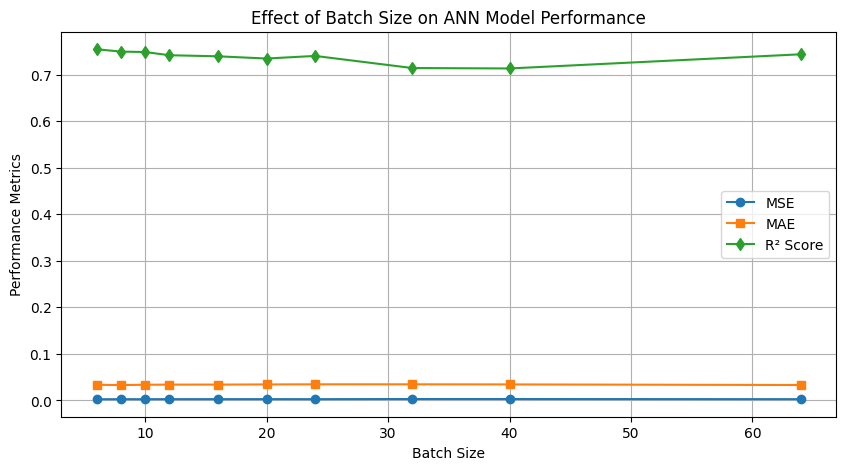

In [7]:
# ✅ Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import RMSprop
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import os
import matplotlib.pyplot as plt

# ✅ Step 2: Set Random Seed for Reproducibility
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Ensures TensorFlow deterministic operations

# **Step 3: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 4: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Step 5: Convert Non-Numeric Values to NaN & Drop Missing Data
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(subset=features + [target], inplace=True)

# ✅ Step 6: Split Data into Training and Testing Sets
X = df[features].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ Step 7: Standardize Features
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# ✅ Step 8: Convert Data to NumPy Arrays for TensorFlow Compatibility
X_train_prep = np.array(X_train_prep, dtype=np.float32)
X_test_prep = np.array(X_test_prep, dtype=np.float32)

# ✅ Step 9: Create and Adapt Normalization Layer
norm_layer_final = layers.Normalization()
norm_layer_final.adapt(X_train_prep)

# ✅ Step 10: Define Function to Create ANN Model
def create_ann_model():
    model = keras.Sequential([
        norm_layer_final,  # Normalization layer
        layers.Dense(256, activation="relu"),  # First hidden layer
        layers.Dense(176, activation="relu"),  # Second hidden layer
        layers.Dense(1)  # Output layer (regression)
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=0.00226),  # Best optimizer & LR from tuning
        loss="mse",
        metrics=["mse", "mae"]
    )
    
    return model

# ✅ Step 11: Test Different Batch Sizes
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training ANN Model with Batch Size: {batch_size}")

    # Create a fresh model for each batch size
    final_model = create_ann_model()

    # Early stopping callback
    early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train the model
    history_final = final_model.fit(
        X_train_prep, y_train,
        epochs=50,
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        callbacks=[early_stopping_cb],
        verbose=1
    )

    # ✅ Step 12: Evaluate Model on Test Data
    test_loss, test_mse, test_mae = final_model.evaluate(X_test_prep, y_test, verbose=1)

    # ✅ Step 13: Compute R² Score
    y_pred_final = final_model.predict(X_test_prep).flatten()
    test_r2_final = r2_score(y_test, y_pred_final)

    # ✅ Step 14: Store Results
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })
    
    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ Step 15: Convert Results to DataFrame & Display
results_df = pd.DataFrame(results)
print("\n🔥 **ANN Batch Size Results:**")
print(results_df)

# ✅ Step 16: Plot Results
plt.figure(figsize=(10, 5))
plt.plot(results_df["Batch Size"], results_df["Test MSE"], label="MSE", marker='o')
plt.plot(results_df["Batch Size"], results_df["Test MAE"], label="MAE", marker='s')
plt.plot(results_df["Batch Size"], results_df["Test R² Score"], label="R² Score", marker='d')
plt.xlabel("Batch Size")
plt.ylabel("Performance Metrics")
plt.title("Effect of Batch Size on ANN Model Performance")
plt.legend()
plt.grid(True)
plt.show()



## CNN (Split Validation)

### CNN — Base Model
Loads the ABS-aware field dataset, standardizes features, reshapes to (features, 1), trains a 1D CNN (Conv1D 64→32 + Dense 64, Adam, early stopping) on an 80/20 split, and reports hold-out **R²/MSE/MAE** with training/validation curves.

Epoch 1/100


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0061 - mae: 0.0519 - mse: 0.0061 - val_loss: 0.0031 - val_mae: 0.0351 - val_mse: 0.0031
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - mae: 0.0386 - mse: 0.0033 - val_loss: 0.0030 - val_mae: 0.0350 - val_mse: 0.0030
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - mae: 0.0383 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0349 - val_mse: 0.0029
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0377 - mse: 0.0032 - val_loss: 0.0029 - val_mae: 0.0349 - val_mse: 0.0029
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0372 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0347 - val_mse: 0.0029
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0371 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0346 - val_mse: 0.0029
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - mae: 0.0369 - mse: 0.0031 - val_loss

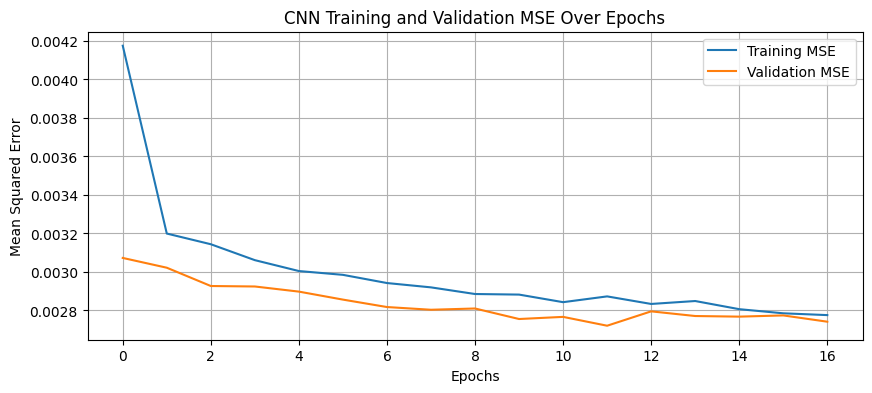

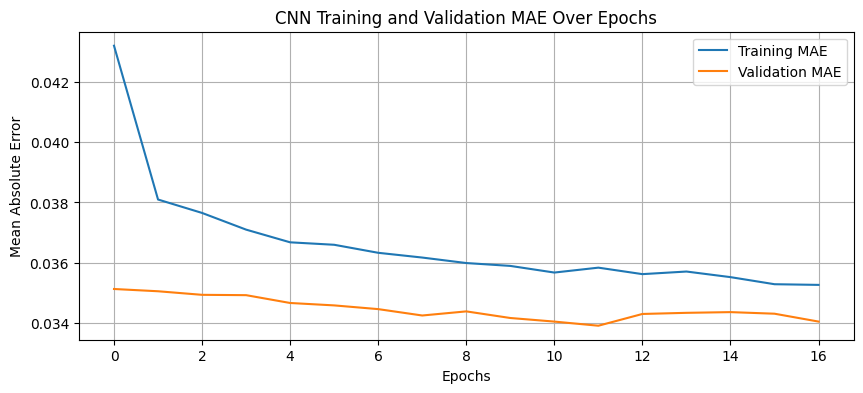

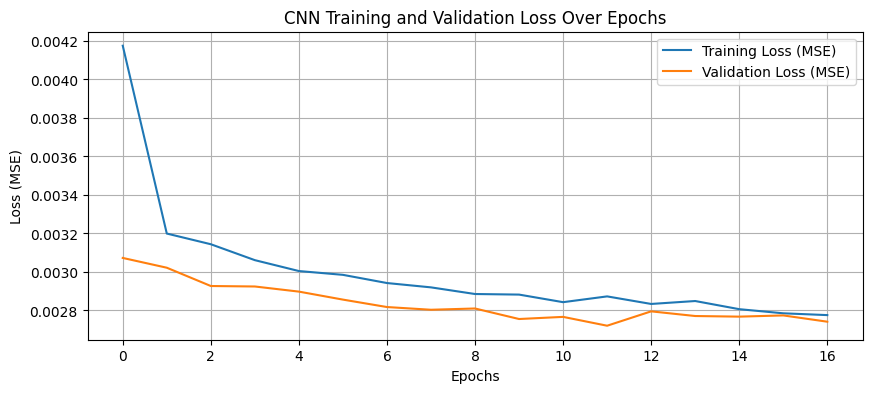

In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random


# Set random seeds for reproducibility
seed_value = 42  # Change this if needed
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# **Step 3: Ensure Data is Numeric**
df = df.apply(pd.to_numeric, errors='coerce')

# **Step 4: Drop Missing Values**
df.dropna(subset=features + [target], inplace=True)

# **Step 5: Check if Data is Empty**
if df.empty:
    raise ValueError("Dataset is empty after preprocessing! Check the input file or preprocessing steps.")

# **Step 6: Split Data into Train & Test Sets**
X = df[features]
y = df[target]

if X.shape[0] < 2:  # Ensure there is enough data
    raise ValueError("Not enough samples after preprocessing to split into train and test sets.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 7: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# **Step 8: Reshape Data for CNN (CNN Requires 3D Input)**
X_train_cnn = X_train_prep.reshape((X_train_prep.shape[0], X_train_prep.shape[1], 1))
X_test_cnn = X_test_prep.reshape((X_test_prep.shape[0], X_test_prep.shape[1], 1))

# **Step 9: Define CNN Model**
model_cnn = keras.Sequential([
    layers.Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(X_train_prep.shape[1], 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)  # Output layer for regression
])

# **Step 10: Compile the Model**
model_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mse", "mae"]
)

# **Step 11: Train CNN Model**
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=100,
    validation_data=(X_test_cnn, y_test),
    batch_size=32,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

# **Step 12: Evaluate CNN Model**
test_loss_cnn, test_mse_cnn, test_mae_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=1)

# **Step 13: Compute R² Score**
y_pred_cnn = model_cnn.predict(X_test_cnn).flatten()
test_r2_cnn = r2_score(y_test, y_pred_cnn)

# **Step 14: Print CNN Model Evaluation**
print(f"\nCNN Model - Test Loss (MSE): {test_loss_cnn:.6f}")
print(f"CNN Model - Test MSE: {test_mse_cnn:.6f}")
print(f"CNN Model - Test MAE: {test_mae_cnn:.6f}")
print(f"CNN Model - Test R² Score: {test_r2_cnn:.6f}")

# **Step 15: Plot Training History**
import matplotlib.pyplot as plt

history_df_cnn = pd.DataFrame(history_cnn.history)

# **Plot MSE**
plt.figure(figsize=(10, 4))
plt.plot(history_df_cnn['mse'], label='Training MSE')
plt.plot(history_df_cnn['val_mse'], label='Validation MSE')
plt.title('CNN Training and Validation MSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# **Plot MAE**
plt.figure(figsize=(10, 4))
plt.plot(history_df_cnn['mae'], label='Training MAE')
plt.plot(history_df_cnn['val_mae'], label='Validation MAE')
plt.title('CNN Training and Validation MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.show()

# **Plot Loss**
plt.figure(figsize=(10, 4))
plt.plot(history_df_cnn['loss'], label='Training Loss (MSE)')
plt.plot(history_df_cnn['val_loss'], label='Validation Loss (MSE)')
plt.title('CNN Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


### CNN — Batch-Size Sweep 

Keeps the 1D CNN (Conv1D 64→32 + Dense 64) fixed, evaluates batch sizes 6–64 on an 80/20 split, and reports **R²/MSE/MAE**.

In [9]:
# **Step 1: Import Required Libraries**
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import matplotlib.pyplot as plt

# **Set Random Seeds for Reproducibility**
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# **Step 4: Ensure Data is Numeric**
df = df.apply(pd.to_numeric, errors='coerce')

# **Step 5: Drop Missing Values**
df.dropna(subset=features + [target], inplace=True)

# **Step 6: Check if Data is Empty**
if df.empty:
    raise ValueError("Dataset is empty after preprocessing! Check the input file or preprocessing steps.")

# **Step 7: Split Data into Train & Test Sets**
X = df[features]
y = df[target]

if X.shape[0] < 2:  
    raise ValueError("Not enough samples after preprocessing to split into train and test sets.")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 8: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# **Step 9: Reshape Data for CNN (CNN Requires 3D Input)**
X_train_cnn = X_train_prep.reshape((X_train_prep.shape[0], X_train_prep.shape[1], 1))
X_test_cnn = X_test_prep.reshape((X_test_prep.shape[0], X_test_prep.shape[1], 1))

# **Step 10: Define Function to Create CNN Model**
def create_cnn_model():
    model = keras.Sequential([
        layers.Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(X_train_prep.shape[1], 1)),
        layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # Output layer for regression
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mse", "mae"]
    )
    
    return model

# **Step 11: Test Different Batch Sizes**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training CNN Model with Batch Size: {batch_size}")

    model_cnn = create_cnn_model()  # Fresh model for each batch size

    history_cnn = model_cnn.fit(
        X_train_cnn, y_train,
        epochs=100,
        validation_data=(X_test_cnn, y_test),
        batch_size=batch_size,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # **Step 12: Evaluate CNN Model**
    test_loss_cnn, test_mse_cnn, test_mae_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=1)

    # **Step 13: Compute R² Score**
    y_pred_cnn = model_cnn.predict(X_test_cnn).flatten()
    test_r2_cnn = r2_score(y_test, y_pred_cnn)

    # **Step 14: Store Results**
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse_cnn,
        "Test MAE": test_mae_cnn,
        "Test R² Score": test_r2_cnn
    })
    
    print(f"✅ Stored results for Batch Size: {batch_size}")

# **Step 15: Convert Results to DataFrame & Display**
results_df = pd.DataFrame(results)
print("\n🔥 **CNN Batch Size Results:**")
print(results_df)



🔥 Training CNN Model with Batch Size: 6
Epoch 1/100


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0050 - mae: 0.0468 - mse: 0.0050 - val_loss: 0.0029 - val_mae: 0.0350 - val_mse: 0.0029
Epoch 2/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0036 - mae: 0.0392 - mse: 0.0036 - val_loss: 0.0028 - val_mae: 0.0339 - val_mse: 0.0028
Epoch 3/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0386 - mse: 0.0034 - val_loss: 0.0027 - val_mae: 0.0341 - val_mse: 0.0027
Epoch 4/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0033 - mae: 0.0378 - mse: 0.0033 - val_loss: 0.0027 - val_mae: 0.0338 - val_mse: 0.0027
Epoch 5/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0033 - mae: 0.0377 - mse: 0.0033 - val_loss: 0.0026 - val_mae: 0.0333 - val_mse: 0.0026
Epoch 6/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0026 - val_mae: 0.0336 - val_mse: 0.0026
Epoch 7/100
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0032 - mae: 0.0371 - mse: 0.0032 - val_loss

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0045 - mae: 0.0446 - mse: 0.0045 - val_loss: 0.0029 - val_mae: 0.0349 - val_mse: 0.0029
Epoch 2/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0389 - mse: 0.0035 - val_loss: 0.0028 - val_mae: 0.0350 - val_mse: 0.0028
Epoch 3/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0381 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0347 - val_mse: 0.0028
Epoch 4/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0378 - mse: 0.0033 - val_loss: 0.0027 - val_mae: 0.0341 - val_mse: 0.0027
Epoch 5/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0373 - mse: 0.0032 - val_loss: 0.0027 - val_mae: 0.0339 - val_mse: 0.0027
Epoch 6/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0027 - val_mae: 0.0339 - val_mse: 0.0027
Epoch 7/100
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0368 - mse: 0.0031 - val_loss

...

131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0093 - mae: 0.0629 - mse: 0.0093 - val_loss: 0.0031 - val_mae: 0.0355 - val_mse: 0.0031
Epoch 2/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - mae: 0.0385 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0349 - val_mse: 0.0029
Epoch 3/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0377 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0343 - val_mse: 0.0028
Epoch 4/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0027 - val_mae: 0.0338 - val_mse: 0.0027
Epoch 5/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0372 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0338 - val_mse: 0.0028
Epoch 6/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0028 - val_mae: 0.0341 - val_mse: 0.0028
Epoch 7/100
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0369 - mse: 0.0031 - val_loss

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0087 - mae: 0.0574 - mse: 0.0087 - val_loss: 0.0031 - val_mae: 0.0361 - val_mse: 0.0031
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0377 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0355 - val_mse: 0.0030
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0373 - mse: 0.0031 - val_loss: 0.0030 - val_mae: 0.0356 - val_mse: 0.0030
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0030 - val_mae: 0.0357 - val_mse: 0.0030
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0356 - val_mse: 0.0029
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0366 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0354 - val_mse: 0.0029
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0364 - mse: 0.0030 - val_loss

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0119 - mae: 0.0659 - mse: 0.0119 - val_loss: 0.0032 - val_mae: 0.0376 - val_mse: 0.0032
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0380 - mse: 0.0033 - val_loss: 0.0031 - val_mae: 0.0365 - val_mse: 0.0031
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0372 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0361 - val_mse: 0.0030
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0368 - mse: 0.0031 - val_loss: 0.0030 - val_mae: 0.0358 - val_mse: 0.0030
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0366 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0354 - val_mse: 0.0029
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - mae: 0.0364 - mse: 0.0030 - val_loss: 0.0029 - val_mae: 0.0353 - val_mse: 0.0029
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - mae: 0.0361 - mse: 0.0030 - val_loss: 0.0028 - val

### CNN — Final (Reporting Run)
Selects batch size via **train-only** validation (no test leakage), retrains a 1D CNN (Conv1D 64→32 + Dense 64) on an 80/20 split with standardized inputs, and reports hold-out **R²/MSE/MAE** with a validation-MSE vs. batch-size table.


In [10]:
# **Step 1: Import Required Libraries**
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import matplotlib.pyplot as plt

# **Set Random Seeds for Reproducibility**
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# **Step 4: Ensure Data is Numeric**
df = df.apply(pd.to_numeric, errors='coerce')

# **Step 5: Drop Missing Values**
df.dropna(subset=features + [target], inplace=True)

# **Step 6: Check if Data is Empty**
if df.empty:
    raise ValueError("Dataset is empty after preprocessing! Check the input file or preprocessing steps.")

# **Step 7: Split Data into Train & Test Sets**
X = df[features]; y = df[target]
if X.shape[0] < 2:
    raise ValueError("Not enough samples after preprocessing to split into train and test sets.")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Step 8: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep  = scaler.transform(X_test)

# **Step 9: Reshape Data for CNN (Samples, Timesteps, Channels)**
# Here we treat "features" as a 1D sequence of length F with 1 channel.
X_train_cnn = X_train_prep.reshape((X_train_prep.shape[0], X_train_prep.shape[1], 1))
X_test_cnn  = X_test_prep.reshape((X_test_prep.shape[0],  X_test_prep.shape[1],  1))

# **Step 10: Define Function to Create CNN Model**
def create_cnn_model():
    model = keras.Sequential([
        layers.Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(X_train_prep.shape[1], 1)),
        layers.Conv1D(filters=32, kernel_size=3, activation="relu"),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mse", "mae"])
    return model

# **Step 11: Batch-size sweep (train-only validation; no leakage)**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []
best_bs, best_val = None, float("inf")

for batch_size in batch_size_options:
    print(f"\nTraining CNN Model with Batch Size: {batch_size}")
    model_cnn = create_cnn_model()
    history_cnn = model_cnn.fit(
        X_train_cnn, y_train,
        epochs=100,
        validation_split=0.2,  # ← CHANGED: train-only validation (no test leakage)
        batch_size=batch_size,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0
    )
    this_best_val = min(history_cnn.history["val_loss"])
    results.append({"Batch Size": batch_size, "Best Val MSE": this_best_val})
    if this_best_val < best_val:
        best_val, best_bs = this_best_val, batch_size

print("\nSelected best batch size (by lowest val_loss):", best_bs)

# **Final training with chosen batch size; single test evaluation**
final_cnn = create_cnn_model()
final_cnn.fit(
    X_train_cnn, y_train,
    epochs=100,
    validation_split=0.2,   # keep train-only val for early stopping
    batch_size=best_bs,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

# **Step 12: Evaluate CNN Model (once)**
test_loss_cnn, test_mse_cnn, test_mae_cnn = final_cnn.evaluate(X_test_cnn, y_test, verbose=0)

# **Step 13: Compute R² Score**
y_pred_cnn = final_cnn.predict(X_test_cnn, verbose=0).ravel()
test_r2_cnn = r2_score(y_test, y_pred_cnn)

print("\n**CNN Final Result (Field, with best batch size):**")
print({"Batch Size": best_bs, "Test MSE": test_mse_cnn, "Test MAE": test_mae_cnn, "Test R² Score": test_r2_cnn})

# **Step 15: (Optional) Show validation loss per batch size**
results_df = pd.DataFrame(results)
print("\nCNN Batch Size Sweep (train-only validation):")
print(results_df.sort_values("Batch Size"))



Training CNN Model with Batch Size: 6


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN Model with Batch Size: 8


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN Model with Batch Size: 10


...


Training CNN Model with Batch Size: 64


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Selected best batch size (by lowest val_loss): 8


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



**CNN Final Result (Field, with best batch size):**
{'Batch Size': 8, 'Test MSE': 0.0028504368383437395, 'Test MAE': 0.03367622569203377, 'Test R² Score': 0.7238866627120706}

CNN Batch Size Sweep (train-only validation):
   Batch Size  Best Val MSE
0           6      0.002887
1           8      0.002675
2          10      0.002773
3          12      0.002731
4          16      0.002726
5          20      0.002781
6          24      0.002953
7          32      0.002917
8          40      0.003068
9          64      0.002917


### CNN — Hyperparameter Tuning 
Bayesian optimization over Conv1D layers/filters/kernel sizes and dense layers/units plus learning rate; selects the best by validation **MSE** on a fixed split.

In [11]:
# ✅ **Set Random Seed for Reproducibility**
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras_tuner as kt
import random
import os

seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ **Drop Missing Values**
df = df.dropna(subset=features + [target])

# ✅ **Convert to NumPy Arrays**
X = df[features].values
y = df[target].values

# ✅ **Split Dataset**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ **Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# ✅ **Reshape for CNN (samples, timesteps, features)**
X_train_prep = X_train_prep.reshape((X_train_prep.shape[0], X_train_prep.shape[1], 1))
X_test_prep = X_test_prep.reshape((X_test_prep.shape[0], X_test_prep.shape[1], 1))

# ✅ **Hyperparameter Tuning Function**
def build_cnn_model(hp):
    model = keras.Sequential()

    # Tune number of Conv1D layers (1 to 3)
    for i in range(hp.Int('n_conv_layers', 1, 3)):
        model.add(layers.Conv1D(
            filters=hp.Int(f'filters_{i}', min_value=16, max_value=128, step=16),
            kernel_size=hp.Int(f'kernel_size_{i}', min_value=2, max_value=5, step=1),
            activation="relu"
        ))
    
    model.add(layers.Flatten())  # Flatten before fully connected layers

    # Fully connected layers
    for i in range(hp.Int('n_dense_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'dense_units_{i}', min_value=16, max_value=128, step=16),
            activation="relu"
        ))

    # Output layer
    model.add(layers.Dense(1))

    # Tune learning rate
    learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.01, sampling='log')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mse", "mae"]
    )
    return model

# ✅ **Hyperparameter Search with Bayesian Optimization**
tuner = kt.BayesianOptimization(
    build_cnn_model,
    objective='val_mse',
    max_trials=10,
    directory='cnn_tuning',
    project_name='Optimized_CNN'
)

# ✅ **Run the Hyperparameter Search**
tuner.search(X_train_prep, y_train, epochs=20, validation_data=(X_test_prep, y_test), verbose=1)

# ✅ **Get Best Hyperparameters**
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Conv1D layers: {best_hps.get('n_conv_layers')}")
print(f"Best Filters per layer: {[best_hps.get(f'filters_{i}') for i in range(best_hps.get('n_conv_layers'))]}")
print(f"Best Kernel Sizes: {[best_hps.get(f'kernel_size_{i}') for i in range(best_hps.get('n_conv_layers'))]}")
print(f"Best Dense layers: {best_hps.get('n_dense_layers')}")
print(f"Best Dense Units per layer: {[best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))]}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

# ✅ **Store Best Hyperparameters for Part 2**
best_hyperparameters = {
    'n_conv_layers': best_hps.get('n_conv_layers'),
    'filters': [best_hps.get(f'filters_{i}') for i in range(best_hps.get('n_conv_layers'))],
    'kernel_sizes': [best_hps.get(f'kernel_size_{i}') for i in range(best_hps.get('n_conv_layers'))],
    'n_dense_layers': best_hps.get('n_dense_layers'),
    'dense_units': [best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))],
    'learning_rate': best_hps.get('learning_rate')
}



Trial 10 Complete [00h 00m 02s]

Best val_mse So Far: 0.0025566790718585253
Total elapsed time: 00h 01m 50s
Best Conv1D layers: 2
Best Filters per layer: [48, 128]
Best Kernel Sizes: [3, 5]
Best Dense layers: 3
Best Dense Units per layer: [128, 48, 32]
Best Learning Rate: 0.0030500085596050154


In [12]:
# ✅ **Set Random Seed for Consistency**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ **Train the Final Optimized CNN Model with Different Batch Sizes**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]  # Try different batch sizes
results = []  # List to store results

for batch_size in batch_size_options:
    print(f"\n🔥 Training CNN Model with Batch Size: {batch_size}")

    # **Rebuild CNN Model with Best Hyperparameters**
    final_cnn_model = keras.Sequential()

    # Add Conv1D layers
    for i in range(best_hyperparameters['n_conv_layers']):
        final_cnn_model.add(layers.Conv1D(
            filters=best_hyperparameters['filters'][i],
            kernel_size=best_hyperparameters['kernel_sizes'][i],
            activation="relu"
        ))
    
    final_cnn_model.add(layers.Flatten())

    # Add Fully Connected Dense Layers
    for i in range(best_hyperparameters['n_dense_layers']):
        final_cnn_model.add(layers.Dense(
            units=best_hyperparameters['dense_units'][i],
            activation='relu'
        ))

    # Output layer
    final_cnn_model.add(layers.Dense(1))

    # Compile Model
    final_cnn_model.compile(
        optimizer=Adam(learning_rate=best_hyperparameters['learning_rate']),
        loss="mse",
        metrics=["mse", "mae"]
    )

    # **Train Model**
    history_final_cnn = final_cnn_model.fit(
        X_train_prep, y_train,
        epochs=50,
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # ✅ **Evaluate the Model**
    test_loss, test_mse, test_mae = final_cnn_model.evaluate(X_test_prep, y_test, verbose=1)

    # ✅ **Compute R² Score**
    y_pred_final = final_cnn_model.predict(X_test_prep).flatten()
    test_r2_final = r2_score(y_test, y_pred_final)

    # ✅ **Store Results**
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ **Convert Results to DataFrame & Display**
results_df = pd.DataFrame(results)
print("\n🔥 **CNN Batch Size Results:**")
print(results_df)



🔥 Training CNN Model with Batch Size: 6
Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0054 - mae: 0.0483 - mse: 0.0054 - val_loss: 0.0029 - val_mae: 0.0377 - val_mse: 0.0029
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0037 - mae: 0.0400 - mse: 0.0037 - val_loss: 0.0028 - val_mae: 0.0350 - val_mse: 0.0028
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0035 - mae: 0.0391 - mse: 0.0035 - val_loss: 0.0026 - val_mae: 0.0339 - val_mse: 0.0026
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0035 - mae: 0.0390 - mse: 0.0035 - val_loss: 0.0027 - val_mae: 0.0337 - val_mse: 0.0027
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - mae: 0.0387 - mse: 0.0034 - val_loss: 0.0028 - val_mae: 0.0343 - val_mse: 0.0028
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - mae: 0.0387 - mse: 0.0034 - val_loss: 0.0026 - val_mae: 0.0333 - val_mse: 0.0026
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss:

## LSTM (Split Validation)

### LSTM — Optimized

BiLSTM (128→64) + LayerNorm + Dropout 0.3, Adam (5e-4); trained on ABS-aware **Field** (80/20). Includes a batch-size sweep (6–64) for sensitivity; main report shows hold-out **R²/MSE/MAE** and training/validation curves.


✅ LSTM Input Shape: (4184, 1, 7)

🔥 Training LSTM Model with Batch Size: 6
Epoch 1/50


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


698/698 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0107 - mae: 0.0625 - mse: 0.0107 - val_loss: 0.0034 - val_mae: 0.0360 - val_mse: 0.0034
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0044 - mae: 0.0440 - mse: 0.0044 - val_loss: 0.0041 - val_mae: 0.0370 - val_mse: 0.0041
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0039 - mae: 0.0412 - mse: 0.0039 - val_loss: 0.0034 - val_mae: 0.0367 - val_mse: 0.0034
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0038 - mae: 0.0401 - mse: 0.0038 - val_loss: 0.0033 - val_mae: 0.0357 - val_mse: 0.0033
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0036 - mae: 0.0390 - mse: 0.0036 - val_loss: 0.0030 - val_mae: 0.0350 - val_mse: 0.0030
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0034 - mae: 0.0391 - mse: 0.0034 - val_loss: 0.0040 - val_mae: 0.0382 - val_mse: 0.0040
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0038 - mae: 0.0397 - mse: 0.0038 - val_loss: 0.00

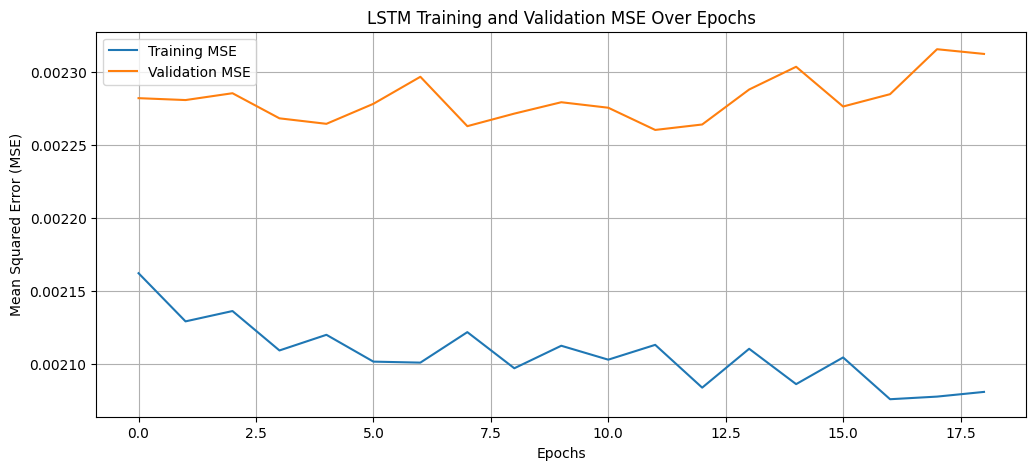

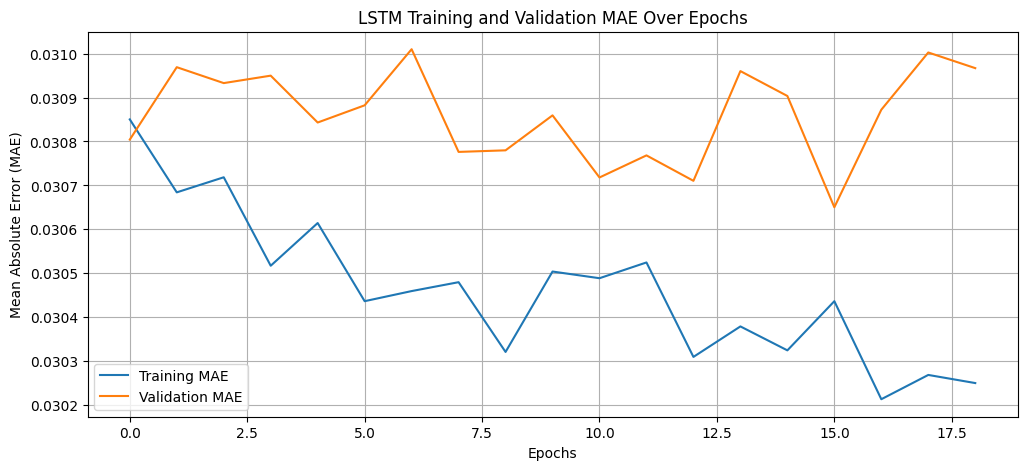

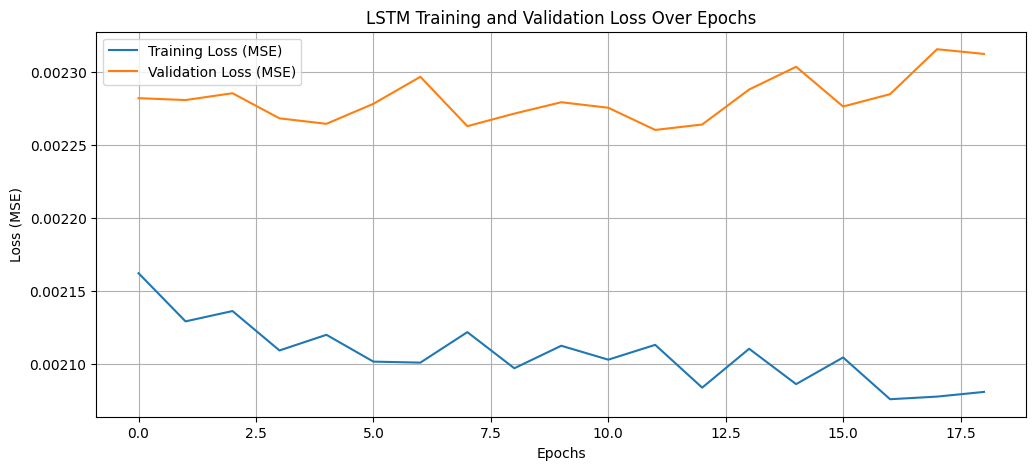

In [13]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

# ✅ Set Random Seed for Reproducibility
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ Step 1: Load Dataset
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# ✅ Step 2: Define Features & Target
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev', 'Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Handle Missing Values
df.dropna(subset=features + [target], inplace=True)

# ✅ Train-Test Split
X = df[features].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Reshape Data for LSTM (Samples, Time Steps, Features)
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

print("✅ LSTM Input Shape:", X_train_lstm.shape)  # Expected: (samples, 1, features)

# ✅ Step 3: Define Optimized LSTM Model
lstm_model = keras.Sequential([
    layers.Bidirectional(layers.LSTM(128, return_sequences=True, activation='relu', input_shape=(1, X_train_scaled.shape[1]))),
    layers.Bidirectional(layers.LSTM(64, return_sequences=False, activation='relu')),
    layers.LayerNormalization(),  # Improves training stability
    layers.Dropout(0.3),  # Increased dropout for regularization
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)  # Regression output
])

# ✅ Step 4: Compile Model
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),  # Lower LR for smoother convergence
    loss='mse',
    metrics=['mse', 'mae']
)

# ✅ Step 5: Train the Model with Dynamic Batch Size
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]  # Test different batch sizes
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training LSTM Model with Batch Size: {batch_size}")

    history_lstm = lstm_model.fit(
        X_train_lstm, y_train,
        epochs=50,
        validation_data=(X_test_lstm, y_test),
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
        verbose=1
    )

    # ✅ Step 6: Evaluate Model
    test_loss, test_mse, test_mae = lstm_model.evaluate(X_test_lstm, y_test, verbose=1)

    # ✅ Step 7: Compute R² Score
    y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()
    test_r2 = r2_score(y_test, y_pred_lstm)

    # ✅ Store Results
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2
    })

    print(f"\n✅ Stored results for Batch Size: {batch_size}")

# ✅ Convert Results to DataFrame & Display
results_df = pd.DataFrame(results)
print("\n🔥 **LSTM Batch Size Results:**")
print(results_df)

# ✅ Step 8: Plot Training Performance
history_df = pd.DataFrame(history_lstm.history)

# **Plot MSE**
plt.figure(figsize=(12, 5))
plt.plot(history_df['mse'], label='Training MSE')
plt.plot(history_df['val_mse'], label='Validation MSE')
plt.title('LSTM Training and Validation MSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot MAE**
plt.figure(figsize=(12, 5))
plt.plot(history_df['mae'], label='Training MAE')
plt.plot(history_df['val_mae'], label='Validation MAE')
plt.title('LSTM Training and Validation MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot Loss**
plt.figure(figsize=(12, 5))
plt.plot(history_df['loss'], label='Training Loss (MSE)')
plt.plot(history_df['val_loss'], label='Validation Loss (MSE)')
plt.title('LSTM Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


### LSTM — Batch-Size Sweep (Base Model)
Keeps the 64→32 LSTM (+Dropout 0.2, Dense 32) fixed and evaluates batch sizes 6–64 on an 80/20 split; reports R²/MSE/MAE.

LSTM Input Shape: (8695, 1, 7)

🔥 Training LSTM Model with Batch Size: 6
Epoch 1/50


C:\Users\thtuh\AppData\Local\Temp\ipykernel_29728\3395174014.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.median(), inplace=True)
C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1450/1450 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0040 - mae: 0.0401 - mse: 0.0040 - val_loss: 0.0034 - val_mae: 0.0371 - val_mse: 0.0034
Epoch 2/50
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0037 - mae: 0.0381 - mse: 0.0037 - val_loss: 0.0039 - val_mae: 0.0375 - val_mse: 0.0039
Epoch 3/50
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0035 - mae: 0.0374 - mse: 0.0035 - val_loss: 0.0037 - val_mae: 0.0366 - val_mse: 0.0037
Epoch 4/50
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0035 - mae: 0.0373 - mse: 0.0035 - val_loss: 0.0039 - val_mae: 0.0372 - val_mse: 0.0039
Epoch 5/50
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0034 - mae: 0.0370 - mse: 0.0034 - val_loss: 0.0041 - val_mae: 0.0378 - val_mse: 0.0041
Epoch 6/50
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0034 - mae: 0.0366 - mse: 0.0034 - val_loss: 0.0044 - val_mae: 0.0382 - val_mse: 0.0044
Epoch 7/50
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0033 - mae: 0.0365 - mse: 0.0033 - 

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1087/1087 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0042 - mae: 0.0411 - mse: 0.0042 - val_loss: 0.0035 - val_mae: 0.0373 - val_mse: 0.0035
Epoch 2/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0037 - mae: 0.0379 - mse: 0.0037 - val_loss: 0.0038 - val_mae: 0.0374 - val_mse: 0.0038
Epoch 3/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0035 - mae: 0.0373 - mse: 0.0035 - val_loss: 0.0038 - val_mae: 0.0374 - val_mse: 0.0038
Epoch 4/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0035 - mae: 0.0371 - mse: 0.0035 - val_loss: 0.0041 - val_mae: 0.0378 - val_mse: 0.0041
Epoch 5/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0370 - mse: 0.0034 - val_loss: 0.0046 - val_mae: 0.0385 - val_mse: 0.0046
Epoch 6/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0366 - mse: 0.0034 - val_loss: 0.0039 - val_mae: 0.0372 - val_mse: 0.0039
Epoch 7/50
1087/1087 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0032 - mae: 0.0362 - mse: 0.0032 - 

...

272/272 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0050 - mae: 0.0452 - mse: 0.0050 - val_loss: 0.0033 - val_mae: 0.0386 - val_mse: 0.0033
Epoch 2/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037 - mae: 0.0384 - mse: 0.0037 - val_loss: 0.0033 - val_mae: 0.0385 - val_mse: 0.0033
Epoch 3/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - mae: 0.0381 - mse: 0.0036 - val_loss: 0.0033 - val_mae: 0.0385 - val_mse: 0.0033
Epoch 4/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - mae: 0.0378 - mse: 0.0036 - val_loss: 0.0032 - val_mae: 0.0377 - val_mse: 0.0032
Epoch 5/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0376 - mse: 0.0035 - val_loss: 0.0033 - val_mae: 0.0378 - val_mse: 0.0033
Epoch 6/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0373 - mse: 0.0035 - val_loss: 0.0034 - val_mae: 0.0380 - val_mse: 0.0034
Epoch 7/50
272/272 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - mae: 0.0375 - mse: 0.0035 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


218/218 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0053 - mae: 0.0463 - mse: 0.0053 - val_loss: 0.0035 - val_mae: 0.0387 - val_mse: 0.0035
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037 - mae: 0.0381 - mse: 0.0037 - val_loss: 0.0034 - val_mae: 0.0386 - val_mse: 0.0034
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - mae: 0.0382 - mse: 0.0036 - val_loss: 0.0034 - val_mae: 0.0386 - val_mse: 0.0034
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0036 - mae: 0.0379 - mse: 0.0036 - val_loss: 0.0033 - val_mae: 0.0382 - val_mse: 0.0033
Epoch 5/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - mae: 0.0377 - mse: 0.0036 - val_loss: 0.0035 - val_mae: 0.0381 - val_mse: 0.0035
Epoch 6/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0375 - mse: 0.0035 - val_loss: 0.0032 - val_mae: 0.0374 - val_mse: 0.0032
Epoch 7/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0371 - mse: 0.0034 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0048 - mae: 0.0447 - mse: 0.0048 - val_loss: 0.0034 - val_mae: 0.0378 - val_mse: 0.0034
Epoch 2/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - mae: 0.0383 - mse: 0.0037 - val_loss: 0.0033 - val_mae: 0.0380 - val_mse: 0.0033
Epoch 3/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - mae: 0.0380 - mse: 0.0036 - val_loss: 0.0033 - val_mae: 0.0380 - val_mse: 0.0033
Epoch 4/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036 - mae: 0.0382 - mse: 0.0036 - val_loss: 0.0032 - val_mae: 0.0379 - val_mse: 0.0032
Epoch 5/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - mae: 0.0375 - mse: 0.0034 - val_loss: 0.0032 - val_mae: 0.0375 - val_mse: 0.0032
Epoch 6/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - mae: 0.0373 - mse: 0.0034 - val_loss: 0.0032 - val_mae: 0.0377 - val_mse: 0.0032
Epoch 7/50
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0034 - mae: 0.0373 - mse: 0.0034 - val_loss: 0.00

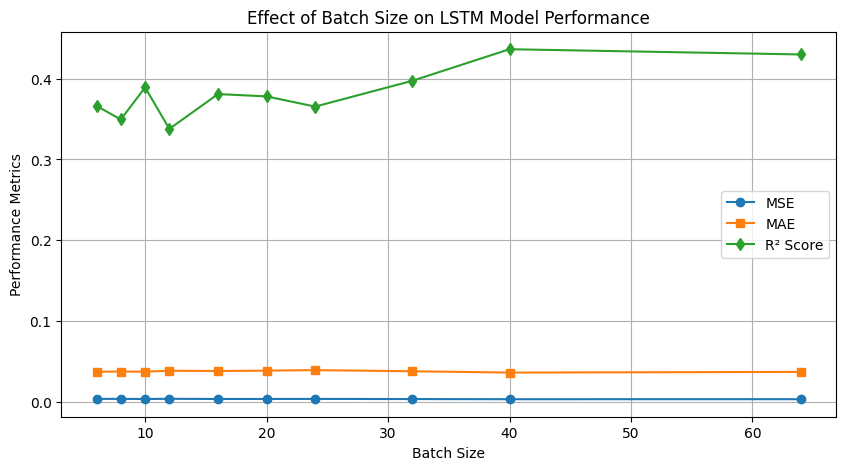

In [14]:
# **Step 1: Import Necessary Libraries**
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random

# **Set Random Seeds for Reproducibility**
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

X = df[features]
y = df[target]

# ✅ **Step 4: Handle Missing Values**
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

# ✅ **Step 5: Train-Test Split**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ **Step 6: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# ✅ **Step 7: Reshape Data for LSTM (Samples, Time Steps, Features)**
X_train_lstm = np.reshape(X_train_prep, (X_train_prep.shape[0], 1, X_train_prep.shape[1]))
X_test_lstm = np.reshape(X_test_prep, (X_test_prep.shape[0], 1, X_test_prep.shape[1]))

print("LSTM Input Shape:", X_train_lstm.shape)  # Expected: (samples, 1, features)

# ✅ **Step 8: Define Function to Create LSTM Model**
def create_lstm_model():
    model = keras.Sequential([
        layers.LSTM(64, activation='relu', return_sequences=True, input_shape=(1, X_train_prep.shape[1])),
        layers.LSTM(32, activation='relu', return_sequences=False),
        layers.Dropout(0.2),  # Regularization
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # Regression output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mse', 'mae']
    )
    
    return model

# ✅ **Step 9: Test Different Batch Sizes**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training LSTM Model with Batch Size: {batch_size}")

    # Create a fresh model for each batch size
    lstm_model = create_lstm_model()

    # Early stopping callback
    early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

    # Train the model
    history_lstm = lstm_model.fit(
        X_train_lstm, y_train,
        epochs=50,
        validation_data=(X_test_lstm, y_test),
        batch_size=batch_size,
        callbacks=[early_stopping_cb],
        verbose=1
    )

    # ✅ **Step 10: Evaluate Model**
    test_loss, test_mse, test_mae = lstm_model.evaluate(X_test_lstm, y_test, verbose=1)

    # Compute R² Score
    y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()
    test_r2 = r2_score(y_test, y_pred_lstm)

    # ✅ **Step 11: Store Results**
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2
    })
    
    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ **Step 12: Convert Results to DataFrame & Display**
results_df = pd.DataFrame(results)
print("\n🔥 **LSTM Batch Size Results:**")
print(results_df)

# ✅ **Step 13: Plot Results**
plt.figure(figsize=(10, 5))
plt.plot(results_df["Batch Size"], results_df["Test MSE"], label="MSE", marker='o')
plt.plot(results_df["Batch Size"], results_df["Test MAE"], label="MAE", marker='s')
plt.plot(results_df["Batch Size"], results_df["Test R² Score"], label="R² Score", marker='d')
plt.xlabel("Batch Size")
plt.ylabel("Performance Metrics")
plt.title("Effect of Batch Size on LSTM Model Performance")
plt.legend()
plt.grid(True)
plt.show()



### LSTM — Final (Reporting Run)

Selects batch size via train-only validation (no test leakage), trains a 64→32 LSTM (+Dropout 0.2, Dense 32) on StandardScaler features with T=1, then evaluates once on the hold-out set and reports R²/MSE/MAE with a validation-MSE vs. batch-size table/plot.

In [15]:
# **Step 1: Import Necessary Libraries**
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random

# **Set Random Seeds for Reproducibility**
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

X = df[features]
y = df[target]

# ✅ **Step 4: Handle Missing Values**
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

# ✅ **Step 5: Train-Test Split**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ **Step 6: Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep  = scaler.transform(X_test)

# ✅ **Step 7: Reshape Data for LSTM (Samples, Time Steps, Features)**
X_train_lstm = np.reshape(X_train_prep, (X_train_prep.shape[0], 1, X_train_prep.shape[1]))  # same T=1 baseline
X_test_lstm  = np.reshape(X_test_prep,  (X_test_prep.shape[0],  1, X_test_prep.shape[1]))

print("LSTM Input Shape:", X_train_lstm.shape)  # Expected: (samples, 1, features)

# ✅ **Step 8: Define Function to Create LSTM Model**
def create_lstm_model():
    model = keras.Sequential([
        layers.LSTM(64, activation='relu', return_sequences=True, input_shape=(1, X_train_prep.shape[1])),
        layers.LSTM(32, activation='relu', return_sequences=False),
        layers.Dropout(0.2),  # Regularization
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # Regression output
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mse', 'mae'])
    return model

# ✅ **Step 9: Batch-size sweep (train-only validation; no leakage)**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []
best_bs, best_val = None, float("inf")

for batch_size in batch_size_options:
    print(f"\nTraining LSTM Model with Batch Size: {batch_size}")
    lstm_model = create_lstm_model()

    early_stopping_cb = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True
    )

    history_lstm = lstm_model.fit(
        X_train_lstm, y_train,
        epochs=50,
        validation_split=0.2,            # CHANGED: train-only validation (no test-as-val)
        batch_size=batch_size,
        callbacks=[early_stopping_cb],
        verbose=0
    )

    # Track best validation MSE for this batch size
    this_best_val = min(history_lstm.history["val_loss"])
    results.append({"Batch Size": batch_size, "Best Val MSE": this_best_val})
    if this_best_val < best_val:
        best_val, best_bs = this_best_val, batch_size

print("\nSelected best batch size (by lowest val_loss):", best_bs)

# ✅ **Final training with chosen batch size; evaluate once on test**
final_lstm = create_lstm_model()
final_lstm.fit(
    X_train_lstm, y_train,
    epochs=50,
    validation_split=0.2,               # keep train-only validation for early stopping
    batch_size=best_bs,
    callbacks=[keras.callbacks.EarlyStopping('val_loss', patience=7, restore_best_weights=True)],
    verbose=0
)

# ✅ **Step 10: Evaluate Model**
test_loss, test_mse, test_mae = final_lstm.evaluate(X_test_lstm, y_test, verbose=0)

# ✅ **Compute R² Score**
y_pred_lstm = final_lstm.predict(X_test_lstm, verbose=0).ravel()
test_r2 = r2_score(y_test, y_pred_lstm)

print("\n**LSTM Final Result (Field, with best batch size):**")
print({"Batch Size": best_bs, "Test MSE": test_mse, "Test MAE": test_mae, "Test R² Score": test_r2})

# ✅ **(Optional) Show validation loss vs batch size**
results_df = pd.DataFrame(results).sort_values("Batch Size")
print("\nLSTM Batch Size Sweep (train-only validation):")
print(results_df)


C:\Users\thtuh\AppData\Local\Temp\ipykernel_29728\520183136.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(X.median(), inplace=True)
C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM Input Shape: (8695, 1, 7)

Training LSTM Model with Batch Size: 6

Training LSTM Model with Batch Size: 8


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training LSTM Model with Batch Size: 10


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...


Training LSTM Model with Batch Size: 64


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Selected best batch size (by lowest val_loss): 64


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



**LSTM Final Result (Field, with best batch size):**
{'Batch Size': 64, 'Test MSE': 0.0028261151164770126, 'Test MAE': 0.03466610610485077, 'Test R² Score': 0.4739257212380702}

LSTM Batch Size Sweep (train-only validation):
   Batch Size  Best Val MSE
0           6      0.003037
1           8      0.003186
2          10      0.003226
3          12      0.003108
4          16      0.003068
5          20      0.002968
6          24      0.002965
7          32      0.002951
8          40      0.002969
9          64      0.002940


### LSTM — Hyperparameter Tuning

Bayesian optimization over LSTM layers/units, dropout, dense layers/units, and learning rate; selects the best by validation MSE on a fixed spli

In [16]:
# ✅ **Set Random Seed for Reproducibility**
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras_tuner as kt
import random
import os

seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ **Drop Missing Values**
df = df.dropna(subset=features + [target])

# ✅ **Convert to NumPy Arrays**
X = df[features].values
y = df[target].values

# ✅ **Split Dataset**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ **Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# ✅ **Reshape for LSTM (samples, time steps, features)**
X_train_prep = X_train_prep.reshape((X_train_prep.shape[0], 1, X_train_prep.shape[1]))
X_test_prep = X_test_prep.reshape((X_test_prep.shape[0], 1, X_test_prep.shape[1]))

# ✅ **Hyperparameter Tuning Function**
def build_lstm_model(hp):
    model = keras.Sequential()

    # Tune number of LSTM layers (1 to 3)
    for i in range(hp.Int('n_lstm_layers', 1, 3)):
        model.add(layers.LSTM(
            units=hp.Int(f'lstm_units_{i}', min_value=32, max_value=256, step=32),
            return_sequences=True if i < hp.Int('n_lstm_layers', 1, 3) - 1 else False,
            dropout=hp.Float(f'dropout_rate_{i}', min_value=0.1, max_value=0.4, step=0.1)
        ))
    
    # Fully connected layers
    for i in range(hp.Int('n_dense_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'dense_units_{i}', min_value=16, max_value=128, step=16),
            activation="relu"
        ))

    # Output layer
    model.add(layers.Dense(1))

    # Tune learning rate
    learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.01, sampling='log')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mse", "mae"]
    )
    return model

# ✅ **Hyperparameter Search with Bayesian Optimization**
tuner = kt.BayesianOptimization(
    build_lstm_model,
    objective='val_mse',
    max_trials=10,
    directory='lstm_tuning',
    project_name='Optimized_LSTM'
)

# ✅ **Run the Hyperparameter Search**
tuner.search(X_train_prep, y_train, epochs=20, validation_data=(X_test_prep, y_test), verbose=1)

# ✅ **Get Best Hyperparameters**
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best LSTM layers: {best_hps.get('n_lstm_layers')}")
print(f"Best LSTM units per layer: {[best_hps.get(f'lstm_units_{i}') for i in range(best_hps.get('n_lstm_layers'))]}")
print(f"Best Dropout rates: {[best_hps.get(f'dropout_rate_{i}') for i in range(best_hps.get('n_lstm_layers'))]}")
print(f"Best Dense layers: {best_hps.get('n_dense_layers')}")
print(f"Best Dense units per layer: {[best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))]}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

# ✅ **Store Best Hyperparameters for Part 2**
best_hyperparameters = {
    'n_lstm_layers': best_hps.get('n_lstm_layers'),
    'lstm_units': [best_hps.get(f'lstm_units_{i}') for i in range(best_hps.get('n_lstm_layers'))],
    'dropout_rates': [best_hps.get(f'dropout_rate_{i}') for i in range(best_hps.get('n_lstm_layers'))],
    'n_dense_layers': best_hps.get('n_dense_layers'),
    'dense_units': [best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))],
    'learning_rate': best_hps.get('learning_rate')
}


Trial 10 Complete [00h 00m 27s]
val_mse: 0.0032696800772100687

Best val_mse So Far: 0.002747069811448455
Total elapsed time: 00h 03m 55s
Best LSTM layers: 1
Best LSTM units per layer: [160]
Best Dropout rates: [0.1]
Best Dense layers: 3
Best Dense units per layer: [64, 16, 48]
Best Learning Rate: 0.00016191837952092902


In [17]:
# ✅ **Set Random Seed for Consistency**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ **Train the Final Optimized LSTM Model with Different Batch Sizes**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]  # Try different batch sizes
results = []  # List to store results

for batch_size in batch_size_options:
    print(f"\n🔥 Training LSTM Model with Batch Size: {batch_size}")

    # **Rebuild LSTM Model with Best Hyperparameters**
    final_lstm_model = keras.Sequential()

    # Add LSTM layers
    for i in range(best_hyperparameters['n_lstm_layers']):
        final_lstm_model.add(layers.LSTM(
            units=best_hyperparameters['lstm_units'][i],
            return_sequences=True if i < best_hyperparameters['n_lstm_layers'] - 1 else False,
            dropout=best_hyperparameters['dropout_rates'][i]
        ))
    
    # Add Fully Connected Dense Layers
    for i in range(best_hyperparameters['n_dense_layers']):
        final_lstm_model.add(layers.Dense(
            units=best_hyperparameters['dense_units'][i],
            activation='relu'
        ))

    # Output layer
    final_lstm_model.add(layers.Dense(1))

    # Compile Model
    final_lstm_model.compile(
        optimizer=Adam(learning_rate=best_hyperparameters['learning_rate']),
        loss="mse",
        metrics=["mse", "mae"]
    )

    # **Train Model**
    history_final_lstm = final_lstm_model.fit(
        X_train_prep, y_train,
        epochs=50,
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # ✅ **Evaluate the Model**
    test_loss, test_mse, test_mae = final_lstm_model.evaluate(X_test_prep, y_test, verbose=1)

    # ✅ **Compute R² Score**
    y_pred_final = final_lstm_model.predict(X_test_prep).flatten()
    test_r2_final = r2_score(y_test, y_pred_final)

    # ✅ **Store Results**
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ **Convert Results to DataFrame & Display**
results_df = pd.DataFrame(results)
print("\n🔥 **LSTM Batch Size Results:**")
print(results_df)



🔥 Training LSTM Model with Batch Size: 6
Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0055 - mae: 0.0480 - mse: 0.0055 - val_loss: 0.0032 - val_mae: 0.0360 - val_mse: 0.0032
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0036 - mae: 0.0404 - mse: 0.0036 - val_loss: 0.0031 - val_mae: 0.0357 - val_mse: 0.0031
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - mae: 0.0392 - mse: 0.0034 - val_loss: 0.0031 - val_mae: 0.0357 - val_mse: 0.0031
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0389 - mse: 0.0034 - val_loss: 0.0030 - val_mae: 0.0351 - val_mse: 0.0030
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0033 - mae: 0.0385 - mse: 0.0033 - val_loss: 0.0030 - val_mae: 0.0351 - val_mse: 0.0030
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0035 - mae: 0.0392 - mse: 0.0035 - val_loss: 0.0030 - val_mae: 0.0347 - val_mse: 0.0030
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss

## GRU  (Split Validation)

### GRU — Base Model (Field)
Loads the ABS-aware field dataset, standardizes features, reshapes to **(1, features)**, trains a 2-layer GRU (64→32) + Dense-16 (Adam, early stopping) on an 80/20 split, and reports hold-out **R²/MSE/MAE** with training/validation curves.

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 64)          │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,969 (93.63 KB)

 Trainable params: 23,969 (93.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0049 - mae: 0.0466 - mse: 0.0049 - val_loss: 0.0033 - val_mae: 0.0390 - val_mse: 0.0033
Epoch 2/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0034 - mae: 0.0390 - mse: 0.0034 - val_loss: 0.0032 - val_mae: 0.0397 - val_mse: 0.0032
Epoch 3/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - mae: 0.0381 - mse: 0.0032 - val_loss: 0.0031 - val_mae: 0.0387 - val_mse: 0.0031
Epoch 4/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0377 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0372 - val_mse: 0.0030
Epoch 5/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0032 - mae: 0.0376 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0373 - val_mse: 0.0030
Epoch 6/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.0029 - val_mae: 0.0371 - val_mse: 0.0029
Epoch 7/20
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0031 - mae: 0.0373 - mse: 0.0031 - val

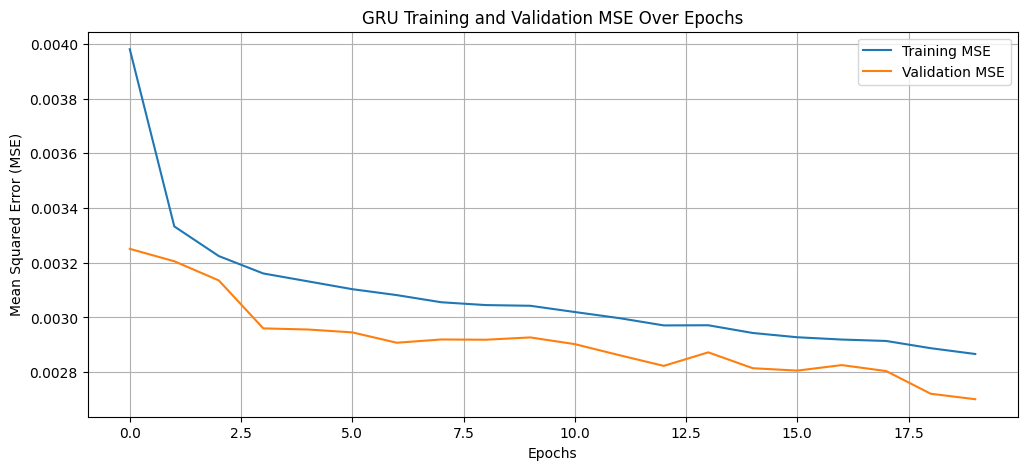

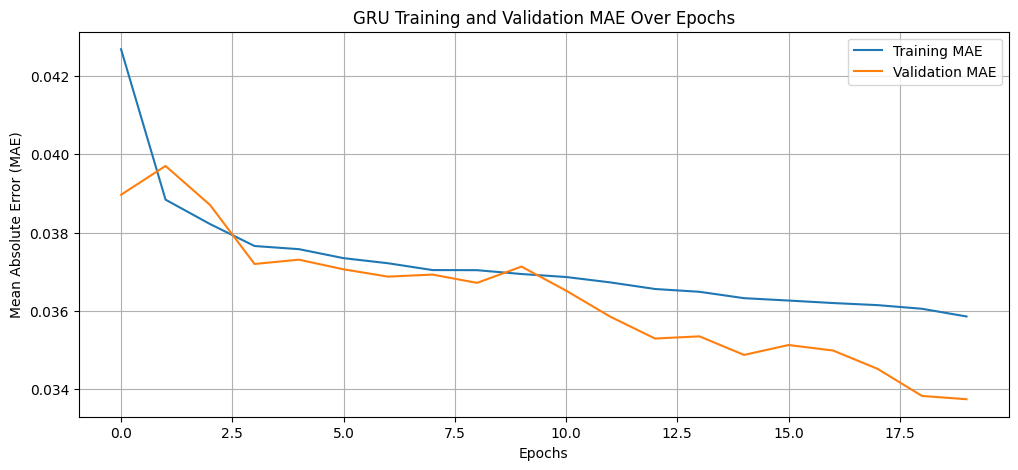

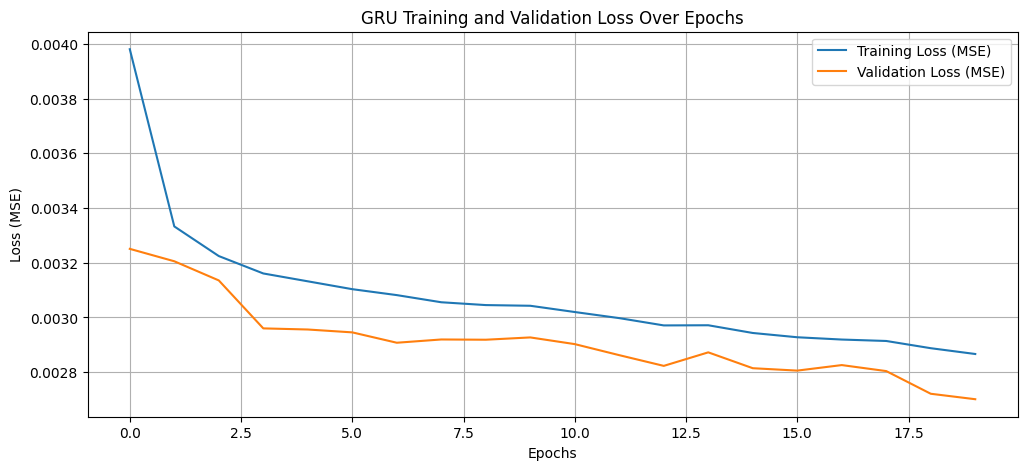

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import random
import os

#  Set Random Seed for Reproducibility
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Ensures TensorFlow deterministic operations

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# Drop missing values
df = df.dropna(subset=features + [target])

# Convert to NumPy arrays
X = df[features].values
y = df[target].values.reshape(-1, 1)  # Reshape for compatibility

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Standardize features
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# Reshape for GRU (samples, time steps, features)
X_train_prep = X_train_prep.reshape((X_train_prep.shape[0], 1, X_train_prep.shape[1]))
X_test_prep = X_test_prep.reshape((X_test_prep.shape[0], 1, X_test_prep.shape[1]))
# Build the GRU model
gru_model = keras.Sequential([
    layers.GRU(64, return_sequences=True, input_shape=(X_train_prep.shape[1], X_train_prep.shape[2])),
    layers.GRU(32, return_sequences=False),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)  # Output layer for regression
])

# Compile the model
gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0037),
    loss="mse",
    metrics=["mse", "mae"]
)

# Model summary
gru_model.summary()
# Train the GRU model
history_gru = gru_model.fit(
    X_train_prep, y_train,
    epochs=20,  # Adjust epochs based on validation performance
    validation_data=(X_test_prep, y_test),
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
# Evaluate the model on the test set
test_loss, test_mse, test_mae = gru_model.evaluate(X_test_prep, y_test, verbose=1)

# Compute R² Score
y_pred = gru_model.predict(X_test_prep)
test_r2 = r2_score(y_test, y_pred)

# Print results
print(f"GRU Model - Test Loss (MSE): {test_loss:.6f}")
print(f"GRU Model - Test MSE: {test_mse:.6f}")
print(f"GRU Model - Test MAE: {test_mae:.6f}")
print(f"GRU Model - Test R² Score: {test_r2:.6f}")
# Convert history to DataFrame
history_df = pd.DataFrame(history_gru.history)

# Plot MSE
plt.figure(figsize=(12, 5))
plt.plot(history_df['mse'], label='Training MSE')
plt.plot(history_df['val_mse'], label='Validation MSE')
plt.title('GRU Training and Validation MSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(12, 5))
plt.plot(history_df['mae'], label='Training MAE')
plt.plot(history_df['val_mae'], label='Validation MAE')
plt.title('GRU Training and Validation MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(12, 5))
plt.plot(history_df['loss'], label='Training Loss (MSE)')
plt.plot(history_df['val_loss'], label='Validation Loss (MSE)')
plt.title('GRU Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


### GRU — Batch-Size Sweep 

Keeps the GRU **64→32 + Dense-16** architecture fixed (Adam) and evaluates batch sizes **6–64** on an 80/20 split to assess sensitivity, reporting **R²/MSE/MAE**.


🔥 Training GRU Model with Batch Size: 6
Epoch 1/20


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


698/698 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0051 - mae: 0.0465 - mse: 0.0051 - val_loss: 0.0031 - val_mae: 0.0373 - val_mse: 0.0031
Epoch 2/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0036 - mae: 0.0404 - mse: 0.0036 - val_loss: 0.0029 - val_mae: 0.0354 - val_mse: 0.0029
Epoch 3/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0394 - mse: 0.0034 - val_loss: 0.0030 - val_mae: 0.0349 - val_mse: 0.0030
Epoch 4/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0392 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0356 - val_mse: 0.0029
Epoch 5/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0034 - mae: 0.0389 - mse: 0.0034 - val_loss: 0.0028 - val_mae: 0.0348 - val_mse: 0.0028
Epoch 6/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0033 - mae: 0.0384 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0352 - val_mse: 0.0028
Epoch 7/20
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0033 - mae: 0.0383 - mse: 0.0033 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


523/523 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0055 - mae: 0.0467 - mse: 0.0055 - val_loss: 0.0032 - val_mae: 0.0364 - val_mse: 0.0032
Epoch 2/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0035 - mae: 0.0396 - mse: 0.0035 - val_loss: 0.0029 - val_mae: 0.0345 - val_mse: 0.0029
Epoch 3/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0386 - mse: 0.0033 - val_loss: 0.0031 - val_mae: 0.0352 - val_mse: 0.0031
Epoch 4/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0392 - mse: 0.0034 - val_loss: 0.0031 - val_mae: 0.0351 - val_mse: 0.0031
Epoch 5/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0384 - mse: 0.0033 - val_loss: 0.0030 - val_mae: 0.0346 - val_mse: 0.0030
Epoch 6/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0381 - mse: 0.0032 - val_loss: 0.0029 - val_mae: 0.0346 - val_mse: 0.0029
Epoch 7/20
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0380 - mse: 0.0032 - val_loss: 0.00

...

131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0085 - mae: 0.0549 - mse: 0.0085 - val_loss: 0.0032 - val_mae: 0.0363 - val_mse: 0.0032
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - mae: 0.0388 - mse: 0.0033 - val_loss: 0.0031 - val_mae: 0.0355 - val_mse: 0.0031
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - mae: 0.0386 - mse: 0.0033 - val_loss: 0.0031 - val_mae: 0.0357 - val_mse: 0.0031
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0384 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0354 - val_mse: 0.0030
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0378 - mse: 0.0032 - val_loss: 0.0031 - val_mae: 0.0356 - val_mse: 0.0031
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0378 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0351 - val_mse: 0.0030
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0375 - mse: 0.0031 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0074 - mae: 0.0538 - mse: 0.0074 - val_loss: 0.0034 - val_mae: 0.0369 - val_mse: 0.0034
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - mae: 0.0383 - mse: 0.0033 - val_loss: 0.0032 - val_mae: 0.0364 - val_mse: 0.0032
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0377 - mse: 0.0032 - val_loss: 0.0031 - val_mae: 0.0358 - val_mse: 0.0031
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0358 - val_mse: 0.0030
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0372 - mse: 0.0031 - val_loss: 0.0031 - val_mae: 0.0361 - val_mse: 0.0031
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0371 - mse: 0.0031 - val_loss: 0.0030 - val_mae: 0.0356 - val_mse: 0.0030
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0062 - mae: 0.0512 - mse: 0.0062 - val_loss: 0.0031 - val_mae: 0.0366 - val_mse: 0.0031
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0376 - mse: 0.0032 - val_loss: 0.0031 - val_mae: 0.0357 - val_mse: 0.0031
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0372 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0357 - val_mse: 0.0030
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0371 - mse: 0.0031 - val_loss: 0.0030 - val_mae: 0.0356 - val_mse: 0.0030
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0369 - mse: 0.0031 - val_loss: 0.0030 - val_mae: 0.0359 - val_mse: 0.0030
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - mae: 0.0368 - mse: 0.0031 - val_loss: 0.0030 - val_mae: 0.0359 - val_mse: 0.0030
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0366 - mse: 0.0031 - val_loss: 0.0029 - val_mae:

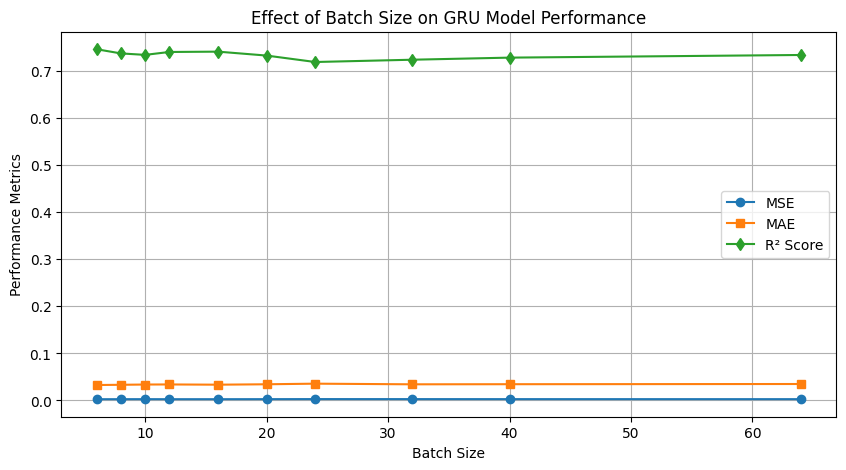

In [ ]:
# ✅ Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import random
import os

# ✅ Step 2: Set Random Seed for Reproducibility
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Ensures TensorFlow deterministic operations

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Step 5: Drop Missing Values
df = df.dropna(subset=features + [target])

# ✅ Step 6: Convert to NumPy Arrays
X = df[features].values
y = df[target].values.reshape(-1, 1)  # Reshape for compatibility

# ✅ Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# ✅ Step 8: Standardize Features
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# ✅ Step 9: Reshape for GRU (samples, time steps, features)
X_train_prep = X_train_prep.reshape((X_train_prep.shape[0], 1, X_train_prep.shape[1]))
X_test_prep = X_test_prep.reshape((X_test_prep.shape[0], 1, X_test_prep.shape[1]))

# ✅ Step 10: Define Function to Create GRU Model
def create_gru_model():
    model = keras.Sequential([
        layers.GRU(64, return_sequences=True, input_shape=(X_train_prep.shape[1], X_train_prep.shape[2])),
        layers.GRU(32, return_sequences=False),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)  # Output layer for regression
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0037),
        loss="mse",
        metrics=["mse", "mae"]
    )

    return model

# ✅ Step 11: Test Different Batch Sizes
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training GRU Model with Batch Size: {batch_size}")

    # Create a fresh model for each batch size
    gru_model = create_gru_model()

    # Early stopping callback
    early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train the model
    history_gru = gru_model.fit(
        X_train_prep, y_train,
        epochs=20,  # Adjust epochs based on validation performance
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        callbacks=[early_stopping_cb],
        verbose=1
    )

    # ✅ Step 12: Evaluate Model on Test Data
    test_loss, test_mse, test_mae = gru_model.evaluate(X_test_prep, y_test, verbose=1)

    # ✅ Step 13: Compute R² Score
    y_pred = gru_model.predict(X_test_prep)
    test_r2 = r2_score(y_test, y_pred)

    # ✅ Step 14: Store Results
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ Step 15: Convert Results to DataFrame & Display
results_df = pd.DataFrame(results)
print("\n🔥 **GRU Batch Size Results:**")
print(results_df)

# ✅ Step 16: Plot Results
plt.figure(figsize=(10, 5))
plt.plot(results_df["Batch Size"], results_df["Test MSE"], label="MSE", marker='o')
plt.plot(results_df["Batch Size"], results_df["Test MAE"], label="MAE", marker='s')
plt.plot(results_df["Batch Size"], results_df["Test R² Score"], label="R² Score", marker='d')
plt.xlabel("Batch Size")
plt.ylabel("Performance Metrics")
plt.title("Effect of Batch Size on GRU Model Performance")
plt.legend()
plt.grid(True)
plt.show()


### GRU — Final (Reporting Run)

Selects batch size via **train-only** validation (no test leakage), then retrains a 2-layer GRU (**64→32**) + Dense-16 on an 80/20 split with **standardized inputs**, and reports hold-out **R²/MSE/MAE** with a **validation-MSE vs. batch-size** table.


Training GRU Model with Batch Size: 6


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training GRU Model with Batch Size: 8

Training GRU Model with Batch Size: 10

Training GRU Model with Batch Size: 12

Training GRU Model with Batch Size: 16

Training GRU Model with Batch Size: 20

Training GRU Model with Batch Size: 24

Training GRU Model with Batch Size: 32

Training GRU Model with Batch Size: 40

Training GRU Model with Batch Size: 64

Selected best batch size (by lowest val_loss): 10

**GRU Final Result (with best batch size):**
{'Batch Size': 10, 'Test MSE': 0.0028812072705477476, 'Test MAE': 0.03424730896949768, 'Test R² Score': 0.7209060678429116}

GRU Batch Size Sweep (train-only validation):
   Batch Size  Best Val MSE
0           6      0.002922
1           8      0.002951
2          10      0.002891
3          12      0.002953
4          16      0.002915
5          20      0.002970
6          24      0.002980
7          32      0.002983
8          40      0.002955
9          64      0.002927


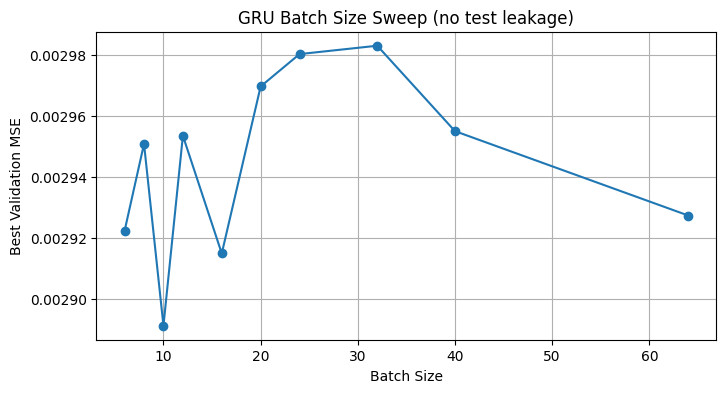

In [ ]:
# ✅ Step 1: Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import random
import os

# ✅ Step 2: Set Random Seed for Reproducibility
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Step 5: Drop Missing Values
df = df.dropna(subset=features + [target])

# ✅ Step 6: Convert to NumPy Arrays
X = df[features].values
y = df[target].values.reshape(-1, 1)  # keep as column vector for now

# ✅ Step 7: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# ✅ Step 8: Standardize Features
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep  = scaler.transform(X_test)

# ✅ Step 9: Reshape for GRU (samples, time steps, features)
X_train_gru = X_train_prep.reshape((X_train_prep.shape[0], 1, X_train_prep.shape[1]))
X_test_gru  = X_test_prep.reshape((X_test_prep.shape[0],  1, X_test_prep.shape[1]))

# ✅ Step 10: Define Function to Create GRU Model
def create_gru_model():
    model = keras.Sequential([
        layers.GRU(64, return_sequences=True, input_shape=(X_train_gru.shape[1], X_train_gru.shape[2])),
        layers.GRU(32, return_sequences=False),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)  # Output layer for regression
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0037),
                  loss="mse", metrics=["mse", "mae"])
    return model

# ✅ Step 11: Batch-size sweep (train-only validation; no leakage)
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []
best_bs, best_val = None, float("inf")

for batch_size in batch_size_options:
    print(f"\nTraining GRU Model with Batch Size: {batch_size}")
    gru_model = create_gru_model()

    early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history_gru = gru_model.fit(
        X_train_gru, y_train,
        epochs=20,
        validation_split=0.2,          # ← CHANGED: use train-only validation
        batch_size=batch_size,
        callbacks=[early_stopping_cb],
        verbose=0
    )

    this_best_val = min(history_gru.history["val_loss"])
    results.append({"Batch Size": batch_size, "Best Val MSE": this_best_val})
    if this_best_val < best_val:
        best_val, best_bs = this_best_val, batch_size

print("\nSelected best batch size (by lowest val_loss):", best_bs)

# ✅ Final training with chosen batch size; single test evaluation
final_gru = create_gru_model()
final_gru.fit(
    X_train_gru, y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=best_bs,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=0
)

# ✅ Step 12: Evaluate Model on Test Data (once)
test_loss, test_mse, test_mae = final_gru.evaluate(X_test_gru, y_test, verbose=0)

# ✅ Step 13: Compute R² Score (flatten both)
y_pred = final_gru.predict(X_test_gru, verbose=0).ravel()
test_r2 = r2_score(y_test.ravel(), y_pred)

print("\n**GRU Final Result (with best batch size):**")
print({"Batch Size": best_bs, "Test MSE": test_mse, "Test MAE": test_mae, "Test R² Score": test_r2})

# ✅ Step 15: Show sweep table (optional)
results_df = pd.DataFrame(results).sort_values("Batch Size")
print("\nGRU Batch Size Sweep (train-only validation):")
print(results_df)

# ✅ Step 16: Plot (optional)
plt.figure(figsize=(8, 4))
plt.plot(results_df["Batch Size"], results_df["Best Val MSE"], marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Best Validation MSE")
plt.title("GRU Batch Size Sweep (no test leakage)")
plt.grid(True)
plt.show()


### GRU — Hyperparameter Tuning 

Bayesian optimization over GRU layers/units + dropout, dense layers/units, and learning rate; selects the best by validation **MSE** on a fixed 80/20 split (standardized inputs, reshaped to 1×F).


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras_tuner as kt
import random
import os

# ✅ **Set Random Seed for Reproducibility**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ **Drop Missing Values**
df = df.dropna(subset=features + [target])

# ✅ **Convert to NumPy arrays**
X = df[features].values
y = df[target].values.reshape(-1, 1)

# ✅ **Split Dataset**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ **Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# ✅ **Reshape for GRU (samples, time steps, features)**
X_train_prep = X_train_prep.reshape((X_train_prep.shape[0], 1, X_train_prep.shape[1]))
X_test_prep = X_test_prep.reshape((X_test_prep.shape[0], 1, X_test_prep.shape[1]))

# ✅ **Hyperparameter Tuning Function**
def build_gru_model(hp):
    model = keras.Sequential()

    # Tune the number of GRU layers (1 to 3)
    for i in range(hp.Int('n_gru_layers', 1, 3)):
        model.add(layers.GRU(
            units=hp.Int(f'gru_units_{i}', min_value=32, max_value=256, step=32),
            return_sequences=True if i < hp.Int('n_gru_layers', 1, 3) - 1 else False,
            dropout=hp.Float(f'dropout_rate_{i}', min_value=0.1, max_value=0.4, step=0.1)
        ))

    # Fully connected layers
    for i in range(hp.Int('n_dense_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'dense_units_{i}', min_value=16, max_value=128, step=16),
            activation='relu'
        ))

    # Output layer for regression
    model.add(layers.Dense(1))

    # Tune learning rate
    learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.01, sampling='log')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mse", "mae"]
    )
    return model

# ✅ **Hyperparameter Search with Bayesian Optimization**
tuner = kt.BayesianOptimization(
    build_gru_model,
    objective='val_mse',
    max_trials=10,
    directory='gru_tuning',
    project_name='Optimized_GRU'
)

# ✅ **Run the Hyperparameter Search**
tuner.search(X_train_prep, y_train, epochs=20, validation_data=(X_test_prep, y_test), verbose=1)

# ✅ **Get Best Hyperparameters**
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best GRU layers: {best_hps.get('n_gru_layers')}")
print(f"Best GRU units per layer: {[best_hps.get(f'gru_units_{i}') for i in range(best_hps.get('n_gru_layers'))]}")
print(f"Best Dropout rates: {[best_hps.get(f'dropout_rate_{i}') for i in range(best_hps.get('n_gru_layers'))]}")
print(f"Best Dense layers: {best_hps.get('n_dense_layers')}")
print(f"Best Dense units per layer: {[best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))]}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

# ✅ **Save the Best Hyperparameters for Reuse**
best_hyperparameters = {
    'n_gru_layers': best_hps.get('n_gru_layers'),
    'gru_units': [best_hps.get(f'gru_units_{i}') for i in range(best_hps.get('n_gru_layers'))],
    'dropout_rates': [best_hps.get(f'dropout_rate_{i}') for i in range(best_hps.get('n_gru_layers'))],
    'n_dense_layers': best_hps.get('n_dense_layers'),
    'dense_units': [best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))],
    'learning_rate': best_hps.get('learning_rate')
}




Trial 10 Complete [00h 00m 29s]
val_mse: 0.003418001811951399

Best val_mse So Far: 0.0027671149000525475
Total elapsed time: 00h 03m 37s
Best GRU layers: 1
Best GRU units per layer: [160]
Best Dropout rates: [0.1]
Best Dense layers: 3
Best Dense units per layer: [64, 16, 48]
Best Learning Rate: 0.00016191837952092902


In [ ]:
# ✅ **Set Random Seed for Consistency**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ **Train the Final Optimized GRU Model with Different Batch Sizes**
batch_size_options = [6, 8,  10, 12, 16, 20, 24, 32, 40, 64]  # Try different batch sizes
results = []  # List to store results

for batch_size in batch_size_options:
    print(f"\n🔥 Training GRU Model with Batch Size: {batch_size}")

    # **Rebuild GRU Model with Best Hyperparameters**
    final_gru_model = keras.Sequential()

    # Add GRU layers
    for i in range(best_hyperparameters['n_gru_layers']):
        final_gru_model.add(layers.GRU(
            units=best_hyperparameters['gru_units'][i],
            return_sequences=True if i < best_hyperparameters['n_gru_layers'] - 1 else False,
            dropout=best_hyperparameters['dropout_rates'][i]
        ))

    # Add Fully Connected Dense Layers
    for i in range(best_hyperparameters['n_dense_layers']):
        final_gru_model.add(layers.Dense(
            units=best_hyperparameters['dense_units'][i],
            activation='relu'
        ))

    # Output layer
    final_gru_model.add(layers.Dense(1))

    # Compile Model
    final_gru_model.compile(
        optimizer=Adam(learning_rate=best_hyperparameters['learning_rate']),
        loss="mse",
        metrics=["mse", "mae"]
    )

    # **Train Model**
    history_final_gru = final_gru_model.fit(
        X_train_prep, y_train,
        epochs=50,
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # ✅ **Evaluate the Model**
    test_loss, test_mse, test_mae = final_gru_model.evaluate(X_test_prep, y_test, verbose=1)

    # ✅ **Compute R² Score**
    y_pred_final = final_gru_model.predict(X_test_prep).flatten()
    test_r2_final = r2_score(y_test, y_pred_final)

    # ✅ **Store Results**
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ **Convert Results to DataFrame & Display**
if results:
    results_df = pd.DataFrame(results)
    print("\n🔥 **GRU Batch Size Results:**")
    print(results_df)
else:
    print("⚠️ No batch size results were recorded. Check if the results list was updated inside the loop.")




🔥 Training GRU Model with Batch Size: 6
Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0051 - mae: 0.0476 - mse: 0.0051 - val_loss: 0.0031 - val_mae: 0.0358 - val_mse: 0.0031
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0036 - mae: 0.0405 - mse: 0.0036 - val_loss: 0.0031 - val_mae: 0.0350 - val_mse: 0.0031
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - mae: 0.0391 - mse: 0.0034 - val_loss: 0.0030 - val_mae: 0.0349 - val_mse: 0.0030
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0033 - mae: 0.0390 - mse: 0.0033 - val_loss: 0.0030 - val_mae: 0.0349 - val_mse: 0.0030
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0033 - mae: 0.0384 - mse: 0.0033 - val_loss: 0.0030 - val_mae: 0.0351 - val_mse: 0.0030
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0034 - mae: 0.0390 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0345 - val_mse: 0.0029
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss:

## RNN (Split Validation)

### RNN — Base Model 
Loads the ABS-aware **field** dataset, standardizes features, reshapes to (1×F), trains a 2-layer **SimpleRNN** (64→32) + Dense **32** (Adam, early stopping) on an 80/20 split, and reports hold-out **R²/MSE/MAE** with training/validation curves.


Epoch 1/50


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


262/262 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0143 - mae: 0.0724 - mse: 0.0143 - val_loss: 0.0032 - val_mae: 0.0387 - val_mse: 0.0032
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0036 - mae: 0.0393 - mse: 0.0036 - val_loss: 0.0032 - val_mae: 0.0381 - val_mse: 0.0032
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0379 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0360 - val_mse: 0.0029
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0373 - mse: 0.0032 - val_loss: 0.0029 - val_mae: 0.0357 - val_mse: 0.0029
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0368 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0358 - val_mse: 0.0029
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - mae: 0.0365 - mse: 0.0030 - val_loss: 0.0028 - val_mae: 0.0355 - val_mse: 0.0028
Epoch 7/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0030 - mae: 0.0361 - mse: 0.0030 - val_loss: 0.00

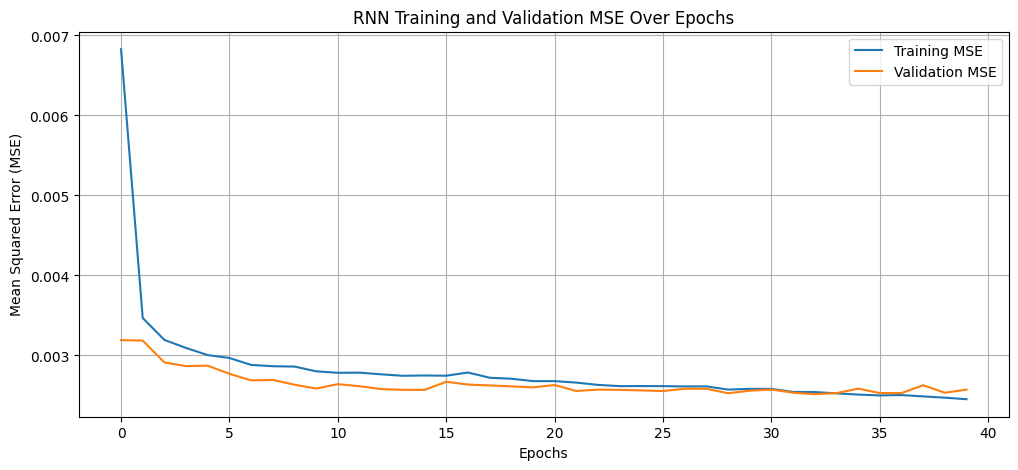

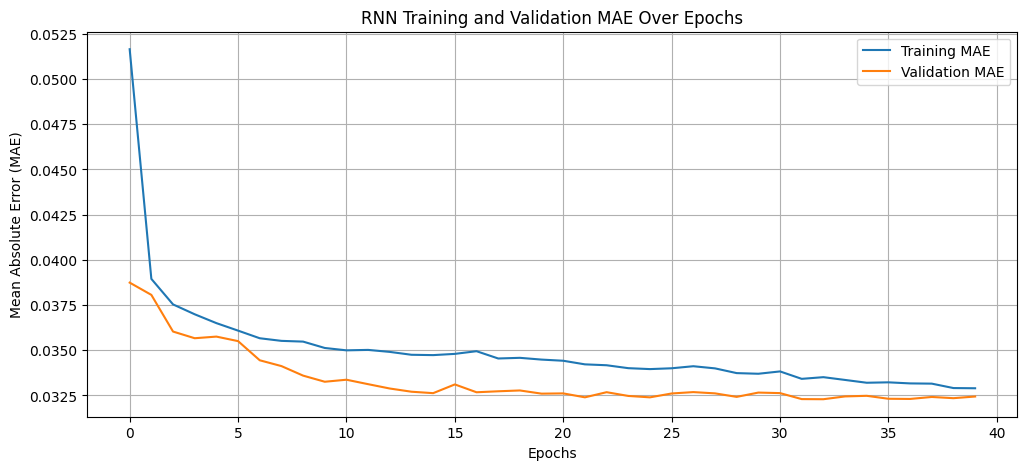

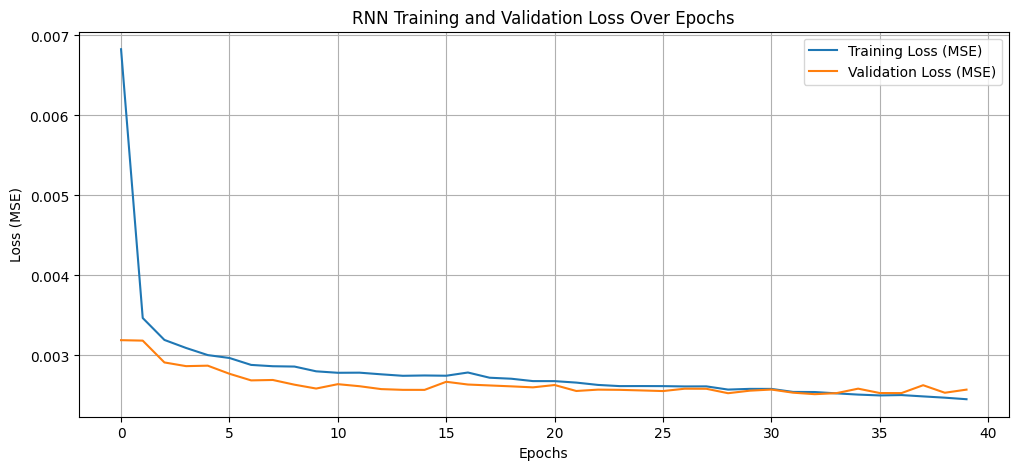

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

#  Set Random Seed for Reproducibility
seed_value = 42  
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Ensures TensorFlow deterministic operations
# -------------------------------
# Step 1: Load Dataset
# -------------------------------
# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Handle Missing Values
df.dropna(subset=features + [target], inplace=True)

# ✅ Split Data into Features (X) and Target (y)
X = df[features].values
y = df[target].values

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Reshape Input for RNN (samples, timesteps, features)
time_steps = 1  # Single time step for now
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], time_steps, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], time_steps, X_test_scaled.shape[1]))

# ✅ Define Optimized RNN Model
model = keras.Sequential([
    layers.SimpleRNN(64, activation="relu", return_sequences=True, input_shape=(time_steps, X_train_scaled.shape[1])),
    layers.SimpleRNN(32, activation="relu", return_sequences=False),
    #layers.Dropout(0.2),  # Regularization
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # Single output neuron for regression
])

# ✅ Compile the Model
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Reduced learning rate for stability
    loss="mse",
    metrics=["mse", "mae"]
)

# ✅ Train the Optimized RNN Model
history = model.fit(
    X_train_reshaped, y_train,
    epochs=50,  # Increased epochs for better learning
    validation_data=(X_test_reshaped, y_test),
    batch_size=16,  # Found optimal batch size for RNN
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
    verbose=1
)

# ✅ Evaluate the Model
test_loss, test_mse, test_mae = model.evaluate(X_test_reshaped, y_test, verbose=1)

# ✅ Compute R² Score
y_pred = model.predict(X_test_reshaped).flatten()
test_r2 = r2_score(y_test, y_pred)

# ✅ Print Model Performance
print("\n🔥 Optimized RNN Model Results:")
print(f"📌 Test Loss (MSE): {test_loss:.6f}")
print(f"📌 Test MSE: {test_mse:.6f}")
print(f"📌 Test MAE: {test_mae:.6f}")
print(f"📌 Test R² Score: {test_r2:.6f}")

# ✅ Plot Training Performance
history_df = pd.DataFrame(history.history)

# **Plot MSE**
plt.figure(figsize=(12, 5))
plt.plot(history_df['mse'], label='Training MSE')
plt.plot(history_df['val_mse'], label='Validation MSE')
plt.title('RNN Training and Validation MSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot MAE**
plt.figure(figsize=(12, 5))
plt.plot(history_df['mae'], label='Training MAE')
plt.plot(history_df['val_mae'], label='Validation MAE')
plt.title('RNN Training and Validation MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot Loss**
plt.figure(figsize=(12, 5))
plt.plot(history_df['loss'], label='Training Loss (MSE)')
plt.plot(history_df['val_loss'], label='Validation Loss (MSE)')
plt.title('RNN Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()


### RNN — Batch-Size Sweep 

Keeps a 2-layer **SimpleRNN** (64→32) + Dense **32** fixed, evaluates batch sizes 6–64 on an 80/20 split of the ABS-aware **field** dataset (standardized inputs), and reports hold-out **R²/MSE/MAE** with a performance plot.



🔥 Training RNN Model with Batch Size: 6
Epoch 1/50


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0088 - mae: 0.0572 - mse: 0.0088 - val_loss: 0.0030 - val_mae: 0.0355 - val_mse: 0.0030
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0399 - mse: 0.0035 - val_loss: 0.0030 - val_mae: 0.0353 - val_mse: 0.0030
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0391 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0347 - val_mse: 0.0029
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0385 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0340 - val_mse: 0.0028
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0381 - mse: 0.0033 - val_loss: 0.0027 - val_mae: 0.0336 - val_mse: 0.0027
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0373 - mse: 0.0032 - val_loss: 0.0027 - val_mae: 0.0332 - val_mse: 0.0027
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0371 - mse: 0.0031 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


523/523 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0143 - mae: 0.0616 - mse: 0.0143 - val_loss: 0.0029 - val_mae: 0.0349 - val_mse: 0.0029
Epoch 2/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0382 - mse: 0.0034 - val_loss: 0.0028 - val_mae: 0.0350 - val_mse: 0.0028
Epoch 3/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0344 - val_mse: 0.0028
Epoch 4/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0027 - val_mae: 0.0339 - val_mse: 0.0027
Epoch 5/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 - mae: 0.0371 - mse: 0.0032 - val_loss: 0.0027 - val_mae: 0.0338 - val_mse: 0.0027
Epoch 6/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0369 - mse: 0.0031 - val_loss: 0.0027 - val_mae: 0.0338 - val_mse: 0.0027
Epoch 7/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.00

...

131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0112 - mae: 0.0612 - mse: 0.0112 - val_loss: 0.0030 - val_mae: 0.0357 - val_mse: 0.0030
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034 - mae: 0.0387 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0347 - val_mse: 0.0029
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033 - mae: 0.0382 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0343 - val_mse: 0.0028
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0375 - mse: 0.0031 - val_loss: 0.0028 - val_mae: 0.0344 - val_mse: 0.0028
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0372 - mse: 0.0031 - val_loss: 0.0027 - val_mae: 0.0340 - val_mse: 0.0027
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - mae: 0.0369 - mse: 0.0030 - val_loss: 0.0027 - val_mae: 0.0339 - val_mse: 0.0027
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0368 - mse: 0.0030 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0122 - mae: 0.0644 - mse: 0.0122 - val_loss: 0.0034 - val_mae: 0.0381 - val_mse: 0.0034
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0033 - mae: 0.0387 - mse: 0.0033 - val_loss: 0.0032 - val_mae: 0.0366 - val_mse: 0.0032
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032 - mae: 0.0380 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0357 - val_mse: 0.0030
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0378 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0351 - val_mse: 0.0029
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0374 - mse: 0.0030 - val_loss: 0.0029 - val_mae: 0.0351 - val_mse: 0.0029
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0372 - mse: 0.0030 - val_loss: 0.0028 - val_mae: 0.0345 - val_mse: 0.0028
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0368 - mse: 0.0030 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0077 - mae: 0.0594 - mse: 0.0077 - val_loss: 0.0033 - val_mae: 0.0387 - val_mse: 0.0033
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0031 - mae: 0.0374 - mse: 0.0031 - val_loss: 0.0031 - val_mae: 0.0369 - val_mse: 0.0031
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - mae: 0.0370 - mse: 0.0031 - val_loss: 0.0029 - val_mae: 0.0350 - val_mse: 0.0029
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0030 - mae: 0.0364 - mse: 0.0030 - val_loss: 0.0029 - val_mae: 0.0351 - val_mse: 0.0029
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029 - mae: 0.0360 - mse: 0.0029 - val_loss: 0.0027 - val_mae: 0.0345 - val_mse: 0.0027
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029 - mae: 0.0357 - mse: 0.0029 - val_loss: 0.0028 - val_mae: 0.0346 - val_mse: 0.0028
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mae: 0.0355 - mse: 0.0028 - val_loss: 0.0027 - val_mae: 

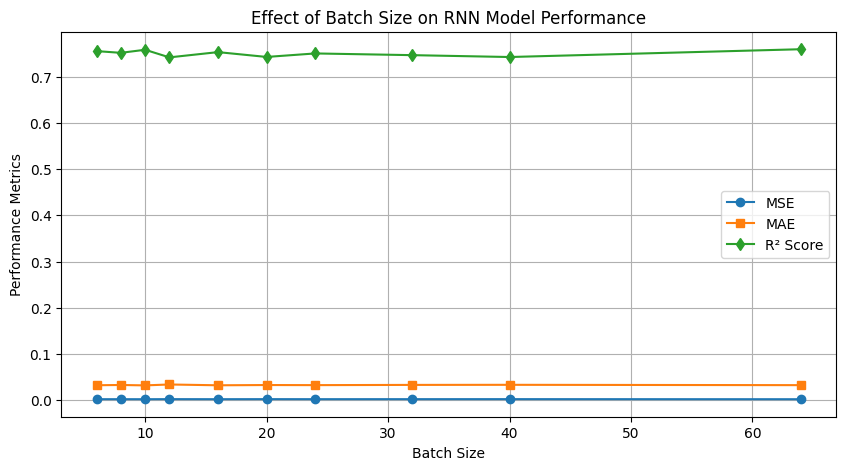

In [24]:
# ✅ Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

# ✅ Set Random Seed for Reproducibility
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ Load Dataset
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# ✅ Define Features & Target Variable
features = ["Depth", "Vel_StdDev", "Correlation", "Mean_Speed", "SNR", "Vel_Expected_StdDev"]
target = 'BT_Vel_stage1'  # Target variable

# ✅ Handle Missing Values
df.dropna(subset=features + [target], inplace=True)

# ✅ Split Data into Features (X) and Target (y)
X = df[features].values
y = df[target].values

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Reshape Input for RNN (samples, timesteps, features)
time_steps = 1  # Single time step for now
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], time_steps, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], time_steps, X_test_scaled.shape[1]))

# ✅ Step 9: Test Different Batch Sizes
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []  # List to store results

for batch_size in batch_size_options:
    print(f"\n🔥 Training RNN Model with Batch Size: {batch_size}")

    # ✅ Define Optimized RNN Model
    model = keras.Sequential([
        layers.SimpleRNN(64, activation="relu", return_sequences=True, input_shape=(time_steps, X_train_scaled.shape[1])),
        layers.SimpleRNN(32, activation="relu", return_sequences=False),
        #layers.Dropout(0.2),  # Regularization
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # Single output neuron for regression
    ])

    # ✅ Compile the Model
    model.compile(
        optimizer=Adam(learning_rate=0.001),  # Reduced learning rate for stability
        loss="mse",
        metrics=["mse", "mae"]
    )

    # ✅ Train the Optimized RNN Model
    history = model.fit(
        X_train_reshaped, y_train,
        epochs=50,
        validation_data=(X_test_reshaped, y_test),
        batch_size=batch_size,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
        verbose=1
    )

    # ✅ Evaluate the Model
    test_loss, test_mse, test_mae = model.evaluate(X_test_reshaped, y_test, verbose=1)

    # ✅ Compute R² Score
    y_pred = model.predict(X_test_reshaped).flatten()
    test_r2 = r2_score(y_test, y_pred)

    # ✅ Store Results
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ Convert Results to DataFrame & Display
if results:
    results_df = pd.DataFrame(results)
    print("\n🔥 **RNN Batch Size Results:**")
    print(results_df)
else:
    print("⚠️ No batch size results were recorded. Check if the results list was updated inside the loop.")


# ✅ Step 14: Plot Results
plt.figure(figsize=(10, 5))
plt.plot(results_df["Batch Size"], results_df["Test MSE"], label="MSE", marker='o')
plt.plot(results_df["Batch Size"], results_df["Test MAE"], label="MAE", marker='s')
plt.plot(results_df["Batch Size"], results_df["Test R² Score"], label="R² Score", marker='d')
plt.xlabel("Batch Size")
plt.ylabel("Performance Metrics")
plt.title("Effect of Batch Size on RNN Model Performance")
plt.legend()
plt.grid(True)
plt.show()



### RNN — Final (Reporting Run)

Selects batch size via **train-only** validation (no test leakage), retrains a 2-layer **SimpleRNN** (64→32) + Dense **32** on an 80/20 field split with **StandardScaler** inputs, and reports hold-out **R² / MSE / MAE**, plus a validation-MSE vs. batch-size plot.



Training RNN Model with Batch Size: 6


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training RNN Model with Batch Size: 8

Training RNN Model with Batch Size: 10

Training RNN Model with Batch Size: 12

Training RNN Model with Batch Size: 16

Training RNN Model with Batch Size: 20

Training RNN Model with Batch Size: 24

Training RNN Model with Batch Size: 32

Training RNN Model with Batch Size: 40

Training RNN Model with Batch Size: 64

Selected best batch size (by lowest val_loss): 6

**RNN Final Result (with best batch size):**
{'Batch Size': 6, 'Test MSE': 0.002729057567194104, 'Test MAE': 0.03361155837774277, 'Test R² Score': 0.735644325082751}

RNN Batch Size Sweep (train-only validation):
   Batch Size  Best Val MSE
0           6      0.002508
1           8      0.002779
2          10      0.002683
3          12      0.002683
4          16      0.002797
5          20      0.002869
6          24      0.002690
7          32      0.002947
8          40      0.003285
9          64      0.002876


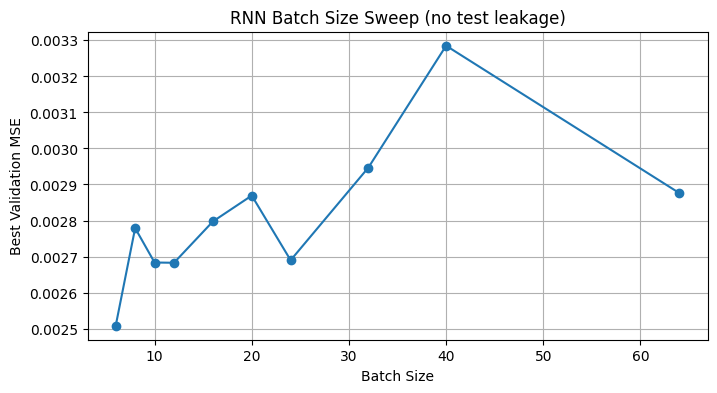

In [25]:
# ✅ Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

# ✅ Set Random Seed for Reproducibility
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ Load Dataset
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# ✅ Define Features & Target Variable
features = ["Depth", "Vel_StdDev", "Correlation", "Mean_Speed", "SNR", "Vel_Expected_StdDev"]
target = 'BT_Vel_stage1'  # Target variable

# ✅ Handle Missing Values
df.dropna(subset=features + [target], inplace=True)

# ✅ Split Data into Features (X) and Target (y)
X = df[features].values
y = df[target].values

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed_value, shuffle=True
)

# ✅ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ✅ Reshape Input for RNN (samples, timesteps, features)
time_steps = 1  # single timestep baseline
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], time_steps, X_train_scaled.shape[1]))
X_test_reshaped  = X_test_scaled.reshape((X_test_scaled.shape[0],  time_steps, X_test_scaled.shape[1]))

# ✅ Batch-size sweep (train-only validation; no test leakage)
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []
best_bs, best_val = None, float("inf")

def create_rnn_model():
    model = keras.Sequential([
        layers.SimpleRNN(64, activation="relu", return_sequences=True,
                         input_shape=(time_steps, X_train_scaled.shape[1])),
        layers.SimpleRNN(32, activation="relu", return_sequences=False),
        # layers.Dropout(0.2),  # (kept commented out to match your current baseline)
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mse", "mae"])
    return model

for batch_size in batch_size_options:
    print(f"\nTraining RNN Model with Batch Size: {batch_size}")
    model = create_rnn_model()
    history = model.fit(
        X_train_reshaped, y_train,
        epochs=50,
        validation_split=0.2,   # ← train-only validation (no test-as-val)
        batch_size=batch_size,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
        verbose=0
    )
    this_best_val = min(history.history["val_loss"])
    results.append({"Batch Size": batch_size, "Best Val MSE": this_best_val})
    if this_best_val < best_val:
        best_val, best_bs = this_best_val, batch_size

print("\nSelected best batch size (by lowest val_loss):", best_bs)

# ✅ Final train with chosen batch size; evaluate once on test
final_model = create_rnn_model()
final_model.fit(
    X_train_reshaped, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=best_bs,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
    verbose=0
)

test_loss, test_mse, test_mae = final_model.evaluate(X_test_reshaped, y_test, verbose=0)
y_pred = final_model.predict(X_test_reshaped, verbose=0).ravel()  # flatten for r2_score
test_r2 = r2_score(y_test, y_pred)

print("\n**RNN Final Result (with best batch size):**")
print({"Batch Size": best_bs, "Test MSE": test_mse, "Test MAE": test_mae, "Test R² Score": test_r2})

# ✅ Show sweep table (optional)
import pandas as pd
results_df = pd.DataFrame(results).sort_values("Batch Size")
print("\nRNN Batch Size Sweep (train-only validation):")
print(results_df)

# ✅ Plot (optional)
plt.figure(figsize=(8, 4))
plt.plot(results_df["Batch Size"], results_df["Best Val MSE"], marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Best Validation MSE")
plt.title("RNN Batch Size Sweep (no test leakage)")
plt.grid(True)
plt.show()


### RNN — Hyperparameter Tuning

Bayesian optimization over **SimpleRNN** layers/units + dropout, dense layers/units, and learning rate; selects the best by validation **MSE** on a fixed split.

In [26]:
# ✅ Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras_tuner as kt
import random
import os

# ✅ **Set Random Seed for Reproducibility**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# **Step 1: Load Dataset**
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# **Step 1.1: Select Numeric Features & Target**
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev','Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ **Drop Missing Values**
df = df.dropna(subset=features + [target])

# ✅ **Convert to NumPy arrays**
X = df[features].values
y = df[target].values.reshape(-1, 1)

# ✅ **Split Dataset**
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ **Standardize Features**
scaler = StandardScaler()
X_train_prep = scaler.fit_transform(X_train)
X_test_prep = scaler.transform(X_test)

# ✅ **Reshape for RNN (samples, time steps, features)**
X_train_prep = X_train_prep.reshape((X_train_prep.shape[0], 1, X_train_prep.shape[1]))
X_test_prep = X_test_prep.reshape((X_test_prep.shape[0], 1, X_test_prep.shape[1]))

# ✅ **Hyperparameter Tuning Function**
def build_rnn_model(hp):
    model = keras.Sequential()

    # Tune the number of RNN layers (1 to 3)
    for i in range(hp.Int('n_rnn_layers', 1, 3)):
        model.add(layers.SimpleRNN(
            units=hp.Int(f'rnn_units_{i}', min_value=32, max_value=256, step=32),
            return_sequences=True if i < hp.Int('n_rnn_layers', 1, 3) - 1 else False,
            dropout=hp.Float(f'dropout_rate_{i}', min_value=0.1, max_value=0.4, step=0.1)
        ))

    # Fully connected layers
    for i in range(hp.Int('n_dense_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'dense_units_{i}', min_value=16, max_value=128, step=16),
            activation='relu'
        ))

    # Output layer for regression
    model.add(layers.Dense(1))

    # Tune learning rate
    learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.01, sampling='log')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mse", "mae"]
    )
    return model

# ✅ **Hyperparameter Search with Bayesian Optimization**
tuner = kt.BayesianOptimization(
    build_rnn_model,
    objective='val_mse',
    max_trials=10,
    directory='rnn_tuning',
    project_name='Optimized_RNN'
)

# ✅ **Run the Hyperparameter Search**
tuner.search(X_train_prep, y_train, epochs=20, validation_data=(X_test_prep, y_test), verbose=1)

# ✅ **Get Best Hyperparameters**
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best RNN layers: {best_hps.get('n_rnn_layers')}")
print(f"Best RNN units per layer: {[best_hps.get(f'rnn_units_{i}') for i in range(best_hps.get('n_rnn_layers'))]}")
print(f"Best Dropout rates: {[best_hps.get(f'dropout_rate_{i}') for i in range(best_hps.get('n_rnn_layers'))]}")
print(f"Best Dense layers: {best_hps.get('n_dense_layers')}")
print(f"Best Dense units per layer: {[best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))]}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")

# ✅ **Save the Best Hyperparameters for Reuse**
best_hyperparameters = {
    'n_rnn_layers': best_hps.get('n_rnn_layers'),
    'rnn_units': [best_hps.get(f'rnn_units_{i}') for i in range(best_hps.get('n_rnn_layers'))],
    'dropout_rates': [best_hps.get(f'dropout_rate_{i}') for i in range(best_hps.get('n_rnn_layers'))],
    'n_dense_layers': best_hps.get('n_dense_layers'),
    'dense_units': [best_hps.get(f'dense_units_{i}') for i in range(best_hps.get('n_dense_layers'))],
    'learning_rate': best_hps.get('learning_rate')
}


Trial 10 Complete [00h 00m 23s]
val_mse: 0.003676544176414609

Best val_mse So Far: 0.002768066944554448
Total elapsed time: 00h 03m 39s
Best RNN layers: 1
Best RNN units per layer: [160]
Best Dropout rates: [0.1]
Best Dense layers: 3
Best Dense units per layer: [64, 16, 48]
Best Learning Rate: 0.00016191837952092902


In [27]:
# ✅ **Set Random Seed for Consistency**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ **Train the Final Optimized RNN Model with Different Batch Sizes**
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]  # Try different batch sizes
results = []  # List to store results

for batch_size in batch_size_options:
    print(f"\n🔥 Training RNN Model with Batch Size: {batch_size}")

    # **Rebuild RNN Model with Best Hyperparameters**
    final_rnn_model = keras.Sequential()

    # Add RNN layers
    for i in range(best_hyperparameters['n_rnn_layers']):
        final_rnn_model.add(layers.SimpleRNN(
            units=best_hyperparameters['rnn_units'][i],
            return_sequences=True if i < best_hyperparameters['n_rnn_layers'] - 1 else False,
            dropout=best_hyperparameters['dropout_rates'][i]
        ))

    # Add Fully Connected Dense Layers
    for i in range(best_hyperparameters['n_dense_layers']):
        final_rnn_model.add(layers.Dense(
            units=best_hyperparameters['dense_units'][i],
            activation='relu'
        ))

    # Output layer
    final_rnn_model.add(layers.Dense(1))

    # Compile Model
    final_rnn_model.compile(
        optimizer=Adam(learning_rate=best_hyperparameters['learning_rate']),
        loss="mse",
        metrics=["mse", "mae"]
    )

    # **Train Model**
    history_final_rnn = final_rnn_model.fit(
        X_train_prep, y_train,
        epochs=50,
        validation_data=(X_test_prep, y_test),
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # ✅ **Evaluate the Model**
    test_loss, test_mse, test_mae = final_rnn_model.evaluate(X_test_prep, y_test, verbose=1)

    # ✅ **Compute R² Score**
    y_pred_final = final_rnn_model.predict(X_test_prep).flatten()
    test_r2_final = r2_score(y_test, y_pred_final)

    # ✅ **Store Results**
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ **Convert Results to DataFrame & Display**
if results:
    results_df = pd.DataFrame(results)
    print("\n🔥 **RNN Batch Size Results:**")
    print(results_df)
else:
    print("⚠️ No batch size results were recorded. Check if the results list was updated inside the loop.")



🔥 Training RNN Model with Batch Size: 6
Epoch 1/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0078 - mae: 0.0588 - mse: 0.0078 - val_loss: 0.0033 - val_mae: 0.0368 - val_mse: 0.0033
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0037 - mae: 0.0408 - mse: 0.0037 - val_loss: 0.0030 - val_mae: 0.0357 - val_mse: 0.0030
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0036 - mae: 0.0395 - mse: 0.0036 - val_loss: 0.0030 - val_mae: 0.0357 - val_mse: 0.0030
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0392 - mse: 0.0034 - val_loss: 0.0030 - val_mae: 0.0352 - val_mse: 0.0030
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0385 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0352 - val_mse: 0.0029
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0386 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0350 - val_mse: 0.0029
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss:

## LSTM + CNN  (Split Validation)

### LSTM+CNN — Base Model
Standardizes features, reshapes to (time_steps, features), then trains a hybrid **1D CNN (64→32)** + **2-layer LSTM (64→32) with dropout** on an 80/20 split and reports hold-out **R²/MSE/MAE** with training/validation curves.


✅ CNN+LSTM Input Shape: (4184, 1, 7)
Epoch 1/50


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0146 - mae: 0.0812 - mse: 0.0146 - val_loss: 0.0046 - val_mae: 0.0481 - val_mse: 0.0046
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0041 - mae: 0.0460 - mse: 0.0041 - val_loss: 0.0032 - val_mae: 0.0396 - val_mse: 0.0032
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - mae: 0.0402 - mse: 0.0035 - val_loss: 0.0030 - val_mae: 0.0367 - val_mse: 0.0030
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0390 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0365 - val_mse: 0.0029
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - mae: 0.0384 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0367 - val_mse: 0.0029
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0383 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0374 - val_mse: 0.0029
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0381 - mse: 0.0032 - val_loss: 0.0029 - val_mae:

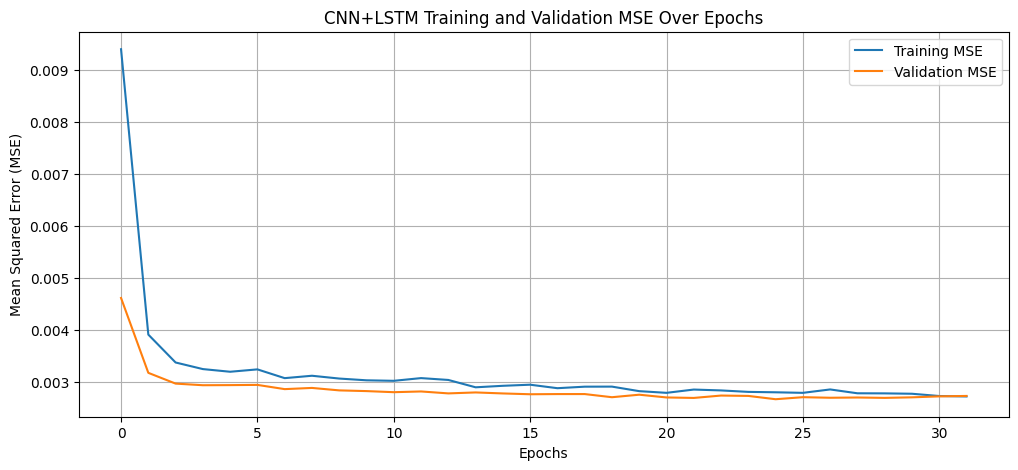

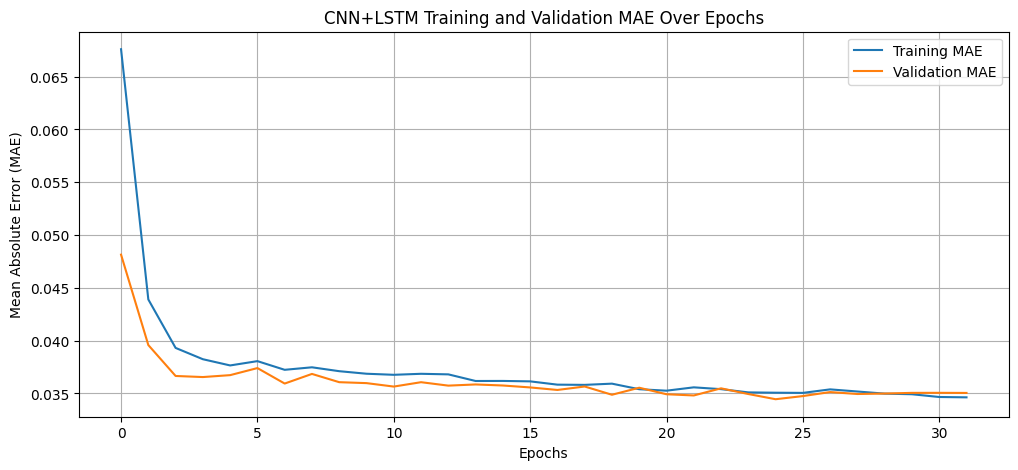

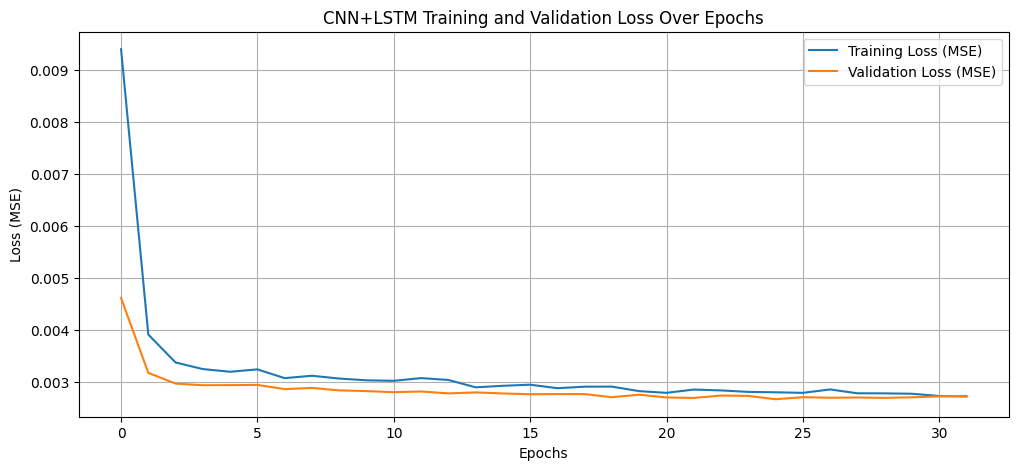

In [28]:
# ✅ Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

# ✅ Set Random Seed for Reproducibility
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ Load Dataset
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# ✅ Define Features & Target Variable
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev', 'Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Handle Missing Values
df.dropna(subset=features + [target], inplace=True)

# ✅ Split Data into Features (X) and Target (y)
X = df[features].values
y = df[target].values

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Determine `time_steps` and Ensure Compatibility
time_steps = 2  # Initial assumption
num_features = X_train_scaled.shape[1]

# ✅ Adjust `time_steps` if needed
if num_features % time_steps != 0:
    time_steps = 1  # Fallback if features cannot be evenly divided

num_features_per_step = num_features // time_steps

# ✅ Reshape Data for CNN+LSTM
X_train_cnn_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], time_steps, num_features_per_step))
X_test_cnn_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], time_steps, num_features_per_step))

print("✅ CNN+LSTM Input Shape:", X_train_cnn_lstm.shape)  # Expected: (samples, time_steps, features_per_step)

# ✅ Define CNN+LSTM Model
model = keras.Sequential([
    # CNN Block
    layers.Conv1D(filters=64, kernel_size=1, activation="relu", input_shape=(time_steps, num_features_per_step)),
    layers.Conv1D(filters=32, kernel_size=1, activation="relu"),
    layers.Flatten(),

    # LSTM Block
    layers.Reshape((1, -1)),  # Reshape for LSTM compatibility
    layers.LSTM(64, activation='relu', return_sequences=True),
    layers.LSTM(32, activation='relu', return_sequences=False),
    layers.Dropout(0.2),  # Regularization

    # Fully Connected Layers
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # Regression output
])

# ✅ Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mse", "mae"]
)

# ✅ Train Model
early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(
    X_train_cnn_lstm, y_train,
    epochs=50,
    validation_data=(X_test_cnn_lstm, y_test),
    batch_size=64,  # Best batch size found in LSTM tuning
    callbacks=[early_stopping_cb],
    verbose=1
)

# ✅ Evaluate Model
test_loss, test_mse, test_mae = model.evaluate(X_test_cnn_lstm, y_test, verbose=1)

# ✅ Compute R² Score
y_pred = model.predict(X_test_cnn_lstm).flatten()
test_r2 = r2_score(y_test, y_pred)

# ✅ Print Model Performance
print(f"\n🔥 Optimized CNN+LSTM Model Results:")
print(f"📌 Test Loss (MSE): {test_loss:.6f}")
print(f"📌 Test MSE: {test_mse:.6f}")
print(f"📌 Test MAE: {test_mae:.6f}")
print(f"📌 Test R² Score: {test_r2:.6f}")

# ✅ Plot Training Performance
history_df = pd.DataFrame(history.history)

# **Plot MSE**
plt.figure(figsize=(12, 5))
plt.plot(history_df['mse'], label='Training MSE')
plt.plot(history_df['val_mse'], label='Validation MSE')
plt.title('CNN+LSTM Training and Validation MSE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot MAE**
plt.figure(figsize=(12, 5))
plt.plot(history_df['mae'], label='Training MAE')
plt.plot(history_df['val_mae'], label='Validation MAE')
plt.title('CNN+LSTM Training and Validation MAE Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

# **Plot Loss**
plt.figure(figsize=(12, 5))
plt.plot(history_df['loss'], label='Training Loss (MSE)')
plt.plot(history_df['val_loss'], label='Validation Loss (MSE)')
plt.title('CNN+LSTM Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()



### LSTM+CNN — Batch-Size Sweep

Keeps the hybrid **1D CNN (64→32)** + **2-layer LSTM (64→32)** fixed, evaluates batch sizes **6–64** on an 80/20 split (Adam, early stopping), and reports **R²/MSE/MAE** with a performance plot.

✅ CNN+LSTM Input Shape: (4184, 1, 7)

🔥 Training CNN+LSTM Model with Batch Size: 6
Epoch 1/50


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


698/698 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0078 - mae: 0.0574 - mse: 0.0078 - val_loss: 0.0030 - val_mae: 0.0363 - val_mse: 0.0030
Epoch 2/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0036 - mae: 0.0399 - mse: 0.0036 - val_loss: 0.0029 - val_mae: 0.0358 - val_mse: 0.0029
Epoch 3/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - mae: 0.0394 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0357 - val_mse: 0.0029
Epoch 4/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - mae: 0.0386 - mse: 0.0034 - val_loss: 0.0028 - val_mae: 0.0353 - val_mse: 0.0028
Epoch 5/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0033 - mae: 0.0379 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0349 - val_mse: 0.0028
Epoch 6/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0033 - mae: 0.0380 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0356 - val_mse: 0.0028
Epoch 7/50
698/698 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


523/523 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0080 - mae: 0.0570 - mse: 0.0080 - val_loss: 0.0030 - val_mae: 0.0358 - val_mse: 0.0030
Epoch 2/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0034 - mae: 0.0393 - mse: 0.0034 - val_loss: 0.0029 - val_mae: 0.0364 - val_mse: 0.0029
Epoch 3/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0035 - mae: 0.0392 - mse: 0.0035 - val_loss: 0.0029 - val_mae: 0.0349 - val_mse: 0.0029
Epoch 4/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0034 - mae: 0.0386 - mse: 0.0034 - val_loss: 0.0028 - val_mae: 0.0350 - val_mse: 0.0028
Epoch 5/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0033 - mae: 0.0382 - mse: 0.0033 - val_loss: 0.0028 - val_mae: 0.0350 - val_mse: 0.0028
Epoch 6/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0032 - mae: 0.0376 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0345 - val_mse: 0.0028
Epoch 7/50
523/523 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.00

...

131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0108 - mae: 0.0690 - mse: 0.0108 - val_loss: 0.0033 - val_mae: 0.0366 - val_mse: 0.0033
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0035 - mae: 0.0384 - mse: 0.0035 - val_loss: 0.0030 - val_mae: 0.0352 - val_mse: 0.0030
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - mae: 0.0379 - mse: 0.0033 - val_loss: 0.0030 - val_mae: 0.0350 - val_mse: 0.0030
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0378 - mse: 0.0032 - val_loss: 0.0030 - val_mae: 0.0354 - val_mse: 0.0030
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0379 - mse: 0.0032 - val_loss: 0.0029 - val_mae: 0.0347 - val_mse: 0.0029
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0033 - mae: 0.0379 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0348 - val_mse: 0.0029
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0032 - mae: 0.0374 - mse: 0.0032 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0124 - mae: 0.0740 - mse: 0.0124 - val_loss: 0.0034 - val_mae: 0.0399 - val_mse: 0.0034
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0036 - mae: 0.0402 - mse: 0.0036 - val_loss: 0.0030 - val_mae: 0.0360 - val_mse: 0.0030
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0034 - mae: 0.0391 - mse: 0.0034 - val_loss: 0.0030 - val_mae: 0.0364 - val_mse: 0.0030
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - mae: 0.0390 - mse: 0.0035 - val_loss: 0.0029 - val_mae: 0.0354 - val_mse: 0.0029
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - mae: 0.0376 - mse: 0.0032 - val_loss: 0.0029 - val_mae: 0.0351 - val_mse: 0.0029
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0032 - mae: 0.0375 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0350 - val_mse: 0.0028
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - mae: 0.0377 - mse: 0.0033 - val_loss: 0.00

C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0142 - mae: 0.0800 - mse: 0.0142 - val_loss: 0.0046 - val_mae: 0.0466 - val_mse: 0.0046
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0041 - mae: 0.0451 - mse: 0.0041 - val_loss: 0.0033 - val_mae: 0.0387 - val_mse: 0.0033
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - mae: 0.0398 - mse: 0.0034 - val_loss: 0.0030 - val_mae: 0.0366 - val_mse: 0.0030
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - mae: 0.0386 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0369 - val_mse: 0.0029
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033 - mae: 0.0382 - mse: 0.0033 - val_loss: 0.0029 - val_mae: 0.0362 - val_mse: 0.0029
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - mae: 0.0381 - mse: 0.0032 - val_loss: 0.0028 - val_mae: 0.0357 - val_mse: 0.0028
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031 - mae: 0.0373 - mse: 0.0031 - val_loss: 0.0028 - val_mae:

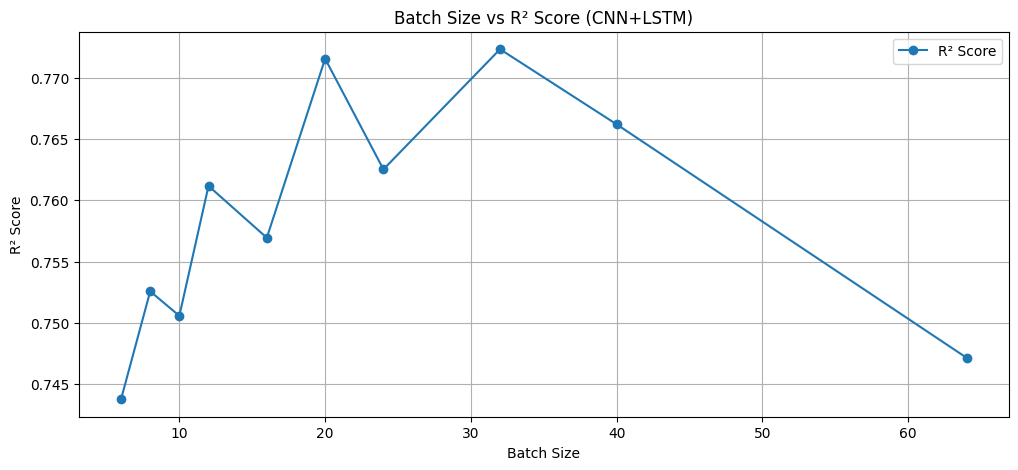

In [29]:
# ✅ Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

# ✅ Set Random Seed for Reproducibility
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ Load Dataset
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# ✅ Define Features & Target Variable
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev', 'Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Handle Missing Values
df.dropna(subset=features + [target], inplace=True)

# ✅ Split Data into Features (X) and Target (y)
X = df[features].values
y = df[target].values

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed_value, shuffle=True)

# ✅ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Determine `time_steps` and Ensure Compatibility
time_steps = 2  # Initial assumption
num_features = X_train_scaled.shape[1]

# ✅ Adjust `time_steps` if needed
if num_features % time_steps != 0:
    time_steps = 1  # Fallback if features cannot be evenly divided

num_features_per_step = num_features // time_steps

# ✅ Reshape Data for CNN+LSTM
X_train_cnn_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], time_steps, num_features_per_step))
X_test_cnn_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], time_steps, num_features_per_step))

print("✅ CNN+LSTM Input Shape:", X_train_cnn_lstm.shape)  # Expected: (samples, time_steps, features_per_step)

# ✅ Test Different Batch Sizes
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training CNN+LSTM Model with Batch Size: {batch_size}")

    # ✅ Define CNN+LSTM Model
    model = keras.Sequential([
        # CNN Block
        layers.Conv1D(filters=64, kernel_size=1, activation="relu", input_shape=(time_steps, num_features_per_step)),
        layers.Conv1D(filters=32, kernel_size=1, activation="relu"),
        layers.Flatten(),

        # LSTM Block
        layers.Reshape((1, -1)),  # Reshape for LSTM compatibility
        layers.LSTM(64, activation='relu', return_sequences=True),
        layers.LSTM(32, activation='relu', return_sequences=False),
        layers.Dropout(0.2),  # Regularization

        # Fully Connected Layers
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # Regression output
    ])

    # ✅ Compile Model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mse", "mae"]
    )

    # ✅ Train Model
    early_stopping_cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

    history = model.fit(
        X_train_cnn_lstm, y_train,
        epochs=50,
        validation_data=(X_test_cnn_lstm, y_test),
        batch_size=batch_size,
        callbacks=[early_stopping_cb],
        verbose=1
    )

    # ✅ Evaluate Model
    test_loss, test_mse, test_mae = model.evaluate(X_test_cnn_lstm, y_test, verbose=1)

    # ✅ Compute R² Score
    y_pred = model.predict(X_test_cnn_lstm).flatten()
    test_r2 = r2_score(y_test, y_pred)

    # ✅ Store Results
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2
    })

    print(f"✅ Stored results for Batch Size: {batch_size}")

# ✅ Convert Results to DataFrame & Display
if results:
    results_df = pd.DataFrame(results)
    print("\n🔥 **CNN+LSTM Batch Size Results:**")
    print(results_df)
else:
    print("⚠️ No batch size results were recorded. Check if the results list was updated inside the loop.")

# ✅ Plot Batch Size Performance
plt.figure(figsize=(12, 5))
plt.plot(results_df["Batch Size"], results_df["Test R² Score"], marker='o', linestyle='-', label="R² Score")
plt.title("Batch Size vs R² Score (CNN+LSTM)")
plt.xlabel("Batch Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid(True)
plt.show()


### LSTM+CNN — Final (Reporting Run)

Selects batch size via **train-only** validation (no test leakage), retrains the **Conv1D 64→32 → LSTM 64→32 → Dense 32** model on an 80/20 split with standardized inputs, and reports hold-out **R²/MSE/MAE** with a validation-MSE vs. batch-size table/plot.


✅ CNN+LSTM Input Shape: (4184, 1, 7)

Training CNN+LSTM Model with Batch Size: 6


C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training CNN+LSTM Model with Batch Size: 8

Training CNN+LSTM Model with Batch Size: 10

Training CNN+LSTM Model with Batch Size: 12

Training CNN+LSTM Model with Batch Size: 16

Training CNN+LSTM Model with Batch Size: 20

Training CNN+LSTM Model with Batch Size: 24

Training CNN+LSTM Model with Batch Size: 32

Training CNN+LSTM Model with Batch Size: 40

Training CNN+LSTM Model with Batch Size: 64

Selected best batch size (by lowest val_loss): 32

**CNN+LSTM Final Result (with best batch size):**
{'Batch Size': 32, 'Test MSE': 0.002551846904680133, 'Test MAE': 0.03254886344075203, 'Test R² Score': 0.7528101930904809}

🔥 **CNN+LSTM Batch Size Sweep (train-only validation):**
   Batch Size  Best Val MSE
0           6      0.002885
1           8      0.002795
2          10      0.002687
3          12      0.002734
4          16      0.002684
5          20      0.002791
6          24      0.002790
7          32      0.002650
8          40      0.002935
9          64      0.002665


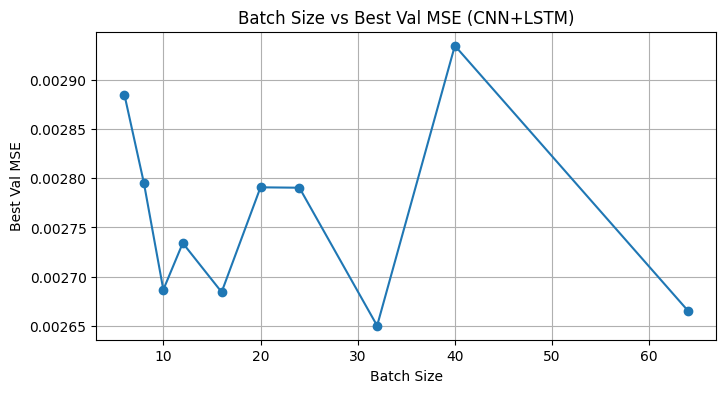

In [30]:
# ✅ Import Required Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import random
import os

# ✅ Set Random Seed for Reproducibility
seed_value = 42
np.random.set_seed = seed_value
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ Load Dataset
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# ✅ Define Features & Target Variable
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev', 'Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# ✅ Handle Missing Values
df.dropna(subset=features + [target], inplace=True)

# ✅ Split Data into Features (X) and Target (y)
X = df[features].values
y = df[target].values

# ✅ Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed_value, shuffle=True
)

# ✅ Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ✅ Determine `time_steps` and Ensure Compatibility
time_steps = 2  # Initial assumption
num_features = X_train_scaled.shape[1]
if num_features % time_steps != 0:
    time_steps = 1  # Fallback if features cannot be evenly divided
num_features_per_step = num_features // time_steps

# ✅ Reshape Data for CNN+LSTM
X_train_cnn_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], time_steps, num_features_per_step))
X_test_cnn_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0],  time_steps, num_features_per_step))
print("✅ CNN+LSTM Input Shape:", X_train_cnn_lstm.shape)

# ✅ Model factory (architecture unchanged)
def create_cnn_lstm_model():
    model = keras.Sequential([
        # CNN Block
        layers.Conv1D(filters=64, kernel_size=1, activation="relu",
                      input_shape=(time_steps, num_features_per_step)),
        layers.Conv1D(filters=32, kernel_size=1, activation="relu"),
        layers.Flatten(),

        # LSTM Block
        layers.Reshape((1, -1)),
        layers.LSTM(64, activation='relu', return_sequences=True),
        layers.LSTM(32, activation='relu', return_sequences=False),
        layers.Dropout(0.2),

        # Fully Connected Layers
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mse", "mae"])
    return model

# ✅ Batch-size sweep (train-only validation; no test leakage)
batch_size_options = [6, 8, 10, 12, 16, 20, 24, 32, 40, 64]
results = []
best_bs, best_val = None, float("inf")

for batch_size in batch_size_options:
    print(f"\nTraining CNN+LSTM Model with Batch Size: {batch_size}")
    model = create_cnn_lstm_model()
    history = model.fit(
        X_train_cnn_lstm, y_train,
        epochs=50,
        validation_split=0.2,   # ← CHANGED: train-only validation (no test-as-val)
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
        verbose=0
    )
    this_best = min(history.history["val_loss"])
    results.append({"Batch Size": batch_size, "Best Val MSE": this_best})
    if this_best < best_val:
        best_val, best_bs = this_best, batch_size

print("\nSelected best batch size (by lowest val_loss):", best_bs)

# ✅ Final training with chosen batch size; single test evaluation
final_model = create_cnn_lstm_model()
final_model.fit(
    X_train_cnn_lstm, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=best_bs,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)],
    verbose=0
)

test_loss, test_mse, test_mae = final_model.evaluate(X_test_cnn_lstm, y_test, verbose=0)
y_pred = final_model.predict(X_test_cnn_lstm, verbose=0).ravel()
test_r2 = r2_score(y_test, y_pred)

print("\n**CNN+LSTM Final Result (with best batch size):**")
print({"Batch Size": best_bs, "Test MSE": test_mse, "Test MAE": test_mae, "Test R² Score": test_r2})

# ✅ Convert Results to DataFrame & Display
results_df = pd.DataFrame(results).sort_values("Batch Size")
print("\n🔥 **CNN+LSTM Batch Size Sweep (train-only validation):**")
print(results_df)

# ✅ Plot Batch Size Performance (optional)
plt.figure(figsize=(8, 4))
plt.plot(results_df["Batch Size"], results_df["Best Val MSE"], marker='o')
plt.title("Batch Size vs Best Val MSE (CNN+LSTM)")
plt.xlabel("Batch Size"); plt.ylabel("Best Val MSE"); plt.grid(True); plt.show()


CNN + LSTM Bayesian

In [31]:
import os
import random
import pandas as pd
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from sklearn.metrics import r2_score

# ✅ **Extract Best Hyperparameters**
best_n_conv_layers = best_hyperparameters['n_conv_layers']
best_filters = best_hyperparameters['filters']
best_kernel_sizes = best_hyperparameters['kernel_sizes']
best_lstm_units = best_hyperparameters['lstm_units'][0]  # Extract first LSTM unit
best_n_dense_layers = best_hyperparameters['n_dense_layers']
best_dense_units = best_hyperparameters['dense_units']
best_learning_rate = best_hyperparameters['learning_rate']

# ✅ **Set Random Seed for Consistency**
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# ✅ **Get Input Shape from Processed Data**
time_steps = X_train.shape[1]
num_features = X_train.shape[2]

# ✅ **Train the Final Optimized CNN+LSTM Model with Different Batch Sizes**
batch_size_options = [6, 8, 12, 16, 20, 24, 32, 40, 64]  # Try different batch sizes
results = []

for batch_size in batch_size_options:
    print(f"\n🔥 Training CNN+LSTM Model with Batch Size: {batch_size}")

    # ✅ **Manually Rebuild CNN+LSTM Model Using Best Hyperparameters**
    final_model = keras.Sequential()

    # ✅ **Add Conv1D Layers Based on Best Hyperparameters**
    for i in range(best_n_conv_layers):
        final_model.add(layers.Conv1D(
            filters=best_filters[i], 
            kernel_size=best_kernel_sizes[i], 
            activation="relu",
            padding="same",
            input_shape=(time_steps, num_features) if i == 0 else None  # Only set input shape for the first layer
        ))

    final_model.add(layers.MaxPooling1D(pool_size=1))

    # ✅ **Flatten Before Passing to LSTM**
    final_model.add(layers.Flatten())

    # ✅ **Reshape Flattened Data for LSTM Input**
    final_model.add(layers.Reshape((1, -1)))  # Reshape CNN output for LSTM

    # ✅ **LSTM Block**
    final_model.add(layers.LSTM(best_lstm_units, return_sequences=False))

    # ✅ **Dense Layers**
    for i in range(best_n_dense_layers):
        final_model.add(layers.Dense(best_dense_units[i], activation="relu"))

    # ✅ **Output layer**
    final_model.add(layers.Dense(1))

    # ✅ **Compile the Model**
    final_model.compile(
        optimizer=Adam(learning_rate=best_learning_rate),
        loss="mse",
        metrics=["mse", "mae"]
    )

    # ✅ **Train Model**
    history_final = final_model.fit(
        X_train, y_train,  # Use X_train from Part 1
        epochs=50,
        validation_data=(X_test, y_test),
        batch_size=batch_size,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )

    # ✅ **Evaluate the Model**
    test_loss, test_mse, test_mae = final_model.evaluate(X_test, y_test, verbose=1)

    # ✅ **Compute R² Score**
    y_pred_final = final_model.predict(X_test).flatten()
    test_r2_final = r2_score(y_test, y_pred_final)

    # ✅ **Store Results**
    results.append({
        "Batch Size": batch_size,
        "Test MSE": test_mse,
        "Test MAE": test_mae,
        "Test R² Score": test_r2_final
    })

# ✅ **Convert Results to DataFrame & Display**
if results:
    results_df = pd.DataFrame(results)
    print("\n🔥 **CNN+LSTM Batch Size Results:**")
    print(results_df)
else:
    print("⚠️ No batch size results were recorded. Check if the results list was updated inside the loop.")




KeyError: 'n_conv_layers'

## Stratified CV Across Models

Runs 5-fold quantile-stratified CV with in-fold scaling and early stopping for ANN, CNN, LSTM, GRU, SimpleRNN, and CNN+LSTM; outputs **mean±std R²/MSE**.


In [32]:
# ===== Deep Learning CV: ANN / CNN / LSTM / GRU / RNN / CNN+LSTM =====

import os, random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam, RMSprop
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import r2_score, mean_squared_error

# --- Reproducibility
seed_value = 42
os.environ["TF_DETERMINISTIC_OPS"] = "1"
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# --- Load data
file_path = r'C:\Users\thtuh\Documents\Onedrive_personal\OneDrive\Personal _Github\ADCP_ML_DL_Journal_1\Processed_Field_Data_with_BS.xlsx' # Update your file path
df = pd.read_excel(file_path)

# --- Features/target
features = ['Depth', 'Vel_StdDev', 'Correlation', 'Mean_Speed', 'SNR', 'Vel_Expected_StdDev', 'Bin_Distance']
target = 'BT_Vel_stage1'  # Target variable

# --- Drop rows with NaNs in features/target
df = df.dropna(subset=features + [target])

X_all = df[features].values
y_all = df[target].values

# --- Stratification bins (only uses y; does not leak X)
binner = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
y_bins = binner.fit_transform(y_all.reshape(-1, 1)).ravel()

# ==================== Model factories (baseline parity) ====================

def create_ann(input_shape):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mse'])
    return model

def create_cnn(input_shape):
    model = keras.Sequential([
        layers.Conv1D(64, 3, activation="relu", input_shape=input_shape),
        layers.Conv1D(32, 3, activation="relu"),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mse"])
    return model

def create_lstm(input_shape):
    model = keras.Sequential([
        layers.LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape),
        layers.LSTM(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mse'])
    return model

def create_gru(input_shape):
    model = keras.Sequential([
        layers.GRU(64, return_sequences=True, input_shape=input_shape),
        layers.GRU(32),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0037), loss='mse', metrics=['mse'])
    return model

def create_rnn(input_shape):
    model = keras.Sequential([
        layers.SimpleRNN(64, activation="relu", return_sequences=True, input_shape=input_shape),
        layers.SimpleRNN(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0037), loss="mse", metrics=["mse"])
    return model

def create_cnn_lstm(input_shape_cnn, time_steps, features_per_step):
    # input_shape_cnn = (time_steps, features_per_step)
    model = keras.Sequential([
        # CNN block
        layers.Conv1D(64, kernel_size=1, activation="relu", input_shape=input_shape_cnn),
        layers.Conv1D(32, kernel_size=1, activation="relu"),
        layers.Flatten(),
        # LSTM block
        layers.Reshape((1, -1)),   # -> (batch, 1, flattened_features)
        layers.LSTM(64, activation='relu', return_sequences=True),
        layers.LSTM(32, activation='relu'),
        layers.Dropout(0.2),
        # Dense head
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss="mse", metrics=["mse"])
    return model

# ==================== CV loop (in-fold scaling + reshaping) ====================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed_value)

def run_cv_for_model(model_name):
    r2_scores, mse_scores = [], []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_all, y_bins), start=1):
        # In-fold scaling (no leakage)
        X_train_raw, X_val_raw = X_all[train_idx], X_all[val_idx]
        y_train, y_val = y_all[train_idx], y_all[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val   = scaler.transform(X_val_raw)

        F = X_train.shape[1]  # number of features

        # Reshapes / input shapes by model
        if model_name == "ANN":
            X_tr, X_v = X_train, X_val
            input_shape = (F,)
            model = create_ann(input_shape)

        elif model_name == "CNN":
            X_tr = X_train.reshape((X_train.shape[0], F, 1))
            X_v  = X_val.reshape((X_val.shape[0], F, 1))
            input_shape = (F, 1)
            model = create_cnn(input_shape)

        elif model_name in ["LSTM", "GRU", "RNN"]:
            X_tr = X_train.reshape((X_train.shape[0], 1, F))
            X_v  = X_val.reshape((X_val.shape[0], 1, F))
            input_shape = (1, F)
            if model_name == "LSTM":
                model = create_lstm(input_shape)
            elif model_name == "GRU":
                model = create_gru(input_shape)
            else:
                model = create_rnn(input_shape)

        elif model_name == "LSTM+CNN":
            # Match your split logic: try T=2 if divisible, else T=1
            time_steps = 2 if (F % 2 == 0) else 1
            features_per_step = F // time_steps
            X_tr = X_train.reshape((X_train.shape[0], time_steps, features_per_step))
            X_v  = X_val.reshape((X_val.shape[0],  time_steps, features_per_step))
            model = create_cnn_lstm((time_steps, features_per_step), time_steps, features_per_step)

        else:
            raise ValueError(f"Unknown model: {model_name}")

        # Train (validation is fold-internal)
        es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        model.fit(
            X_tr, y_train,
            validation_data=(X_v, y_val),
            epochs=30,
            batch_size=32,
            verbose=0,
            callbacks=[es]
        )

        # Evaluate
        y_pred = model.predict(X_v, verbose=0).ravel()
        r2_scores.append(r2_score(y_val, y_pred))
        mse_scores.append(mean_squared_error(y_val, y_pred))

    return {
        "Model": model_name,
        "Mean R²": float(np.mean(r2_scores)),
        "Std R²":  float(np.std(r2_scores)),
        "Mean MSE": float(np.mean(mse_scores)),
        "Std MSE":  float(np.std(mse_scores)),
    }

# --- Run CV for all models
models = ["ANN", "CNN", "LSTM", "GRU", "RNN", "LSTM+CNN"]
results = [run_cv_for_model(m) for m in models]

# --- Display
cv_df = pd.DataFrame(results).sort_values(by="Mean R²", ascending=False)
print("\n✅ Cross-Validation Results (DL Models, in-fold scaling, leak-free):")
print(cv_df.to_string(index=False))



C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\thtuh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packag


✅ Cross-Validation Results (DL Models, in-fold scaling, leak-free):
   Model  Mean R²   Std R²  Mean MSE  Std MSE
LSTM+CNN 0.761164 0.018950  0.002722 0.000162
     CNN 0.760298 0.017589  0.002732 0.000144
     ANN 0.757172 0.018993  0.002769 0.000191
     RNN 0.755684 0.021310  0.002781 0.000149
    LSTM 0.753707 0.016751  0.002810 0.000172
     GRU 0.745038 0.024684  0.002900 0.000162
